# Measurement analysis

This notebook carries out the descriptive and comparative measurement analysis for the 3DFin and RayCloudTools (RCT) workflows.

Only processed datasets created by the reproducible data-preparation notebooks are used as inputs.

The analysis includes:

- individual-tree error distributions before and after quality control;
- final post-QC DBH and TH performance;
- construction of common-tree samples for direct comparison between 3DFin and RCT;
- paired bootstrap comparison of RMSE between the two workflows.

Mixed-effects modelling and the associated robustness analyses are carried out separately in `04_mixed_effects_analysis.ipynb`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# Find the main dissertation-analysis project folder
def find_project_root(start_path):
    """Find the dissertation-analysis project folder."""

    start_path = Path(start_path).resolve()

    for folder in [start_path, *start_path.parents]:
        if (
            (folder / "data").is_dir()
            and (folder / "notebooks").is_dir()
        ):
            return folder

    raise FileNotFoundError(
        "Could not find the dissertation-analysis project root."
    )


# Find the project root from the notebook's current location
PROJECT_DIR = find_project_root(Path.cwd())


# Define the main processed-data and results folders used in the measurement analysis
PROCESSED_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
)

FIGURES_DIR = (
    RESULTS_DIR
    / "figures"
)

TABLES_DIR = (
    RESULTS_DIR
    / "tables"
)


# Create the output folders if they do not already exist
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print(
    f"Project root found: {PROJECT_DIR.name}"
)

Project root found: dissertation-analysis


In [2]:
# Helper used for checks throughout the analysis

def require(condition, message):
    """Stop the notebook if an expected check fails."""

    if not condition:
        raise AssertionError(message)

In [3]:
# Load the processed per-tree measurement datasets produced by the RCT and 3DFin preparation notebooks

RCT_FILE = (
    PROCESSED_DIR
    / "rct"
    / "rct_before_after_per_tree.csv"
)

DFIN_FILE = (
    PROCESSED_DIR
    / "3dfin"
    / "3dfin_measurements_per_tree.csv"
)


rct = pd.read_csv(RCT_FILE)
dfin = pd.read_csv(DFIN_FILE)


# Check the size and available fields in each processed dataset before starting the measurement analysis
print("RCT")
print("Shape:", rct.shape)
print("Columns:")
print(rct.columns.tolist())

print("\n" + "=" * 70)

print("3DFin")
print("Shape:", dfin.shape)
print("Columns:")
print(dfin.columns.tolist())

RCT
Shape: (150, 22)
Columns:
['Terrain', 'Scanner', 'segment_id', 'GT_ID', 'GT_TH', 'before_TH', 'after_TH', 'before_TH_error', 'after_TH_error', 'before_TH_abs_error', 'after_TH_abs_error', 'TH_delta_abs_error', 'GT_DBH', 'before_DBH', 'after_DBH', 'before_DBH_error', 'after_DBH_error', 'before_DBH_abs_error', 'after_DBH_abs_error', 'DBH_delta_abs_error', 'attribute_value_source', 'source_clean_file']

3DFin
Shape: (525, 12)
Columns:
['Terrain', 'Scanner', 'GT_ID', 'Tree_ID', 'Attribute', 'Stage', 'GT_value', 'Predicted_value', 'Error', 'Absolute_error', 'ID_confidence', 'TH_validated']


In [4]:
# Check that the processed RCT error columns are consistent with the underlying GT and before/after-QC measurement values

for attribute in ["TH", "DBH"]:

    gt = rct[f"GT_{attribute}"]

    before = rct[f"before_{attribute}"]
    after = rct[f"after_{attribute}"]

    before_error = rct[f"before_{attribute}_error"]
    after_error = rct[f"after_{attribute}_error"]

    before_abs = rct[f"before_{attribute}_abs_error"]
    after_abs = rct[f"after_{attribute}_abs_error"]

    delta_abs = rct[f"{attribute}_delta_abs_error"]


    # Signed error should equal scanner estimate minus GT
    require(
        np.allclose(
            before_error,
            before - gt,
            equal_nan=True,
        ),
        f"RCT {attribute}: before-QC signed errors are inconsistent.",
    )

    require(
        np.allclose(
            after_error,
            after - gt,
            equal_nan=True,
        ),
        f"RCT {attribute}: after-QC signed errors are inconsistent.",
    )


    # Absolute error should be the magnitude of the signed error
    require(
        np.allclose(
            before_abs,
            np.abs(before_error),
            equal_nan=True,
        ),
        f"RCT {attribute}: before-QC absolute errors are inconsistent.",
    )

    require(
        np.allclose(
            after_abs,
            np.abs(after_error),
            equal_nan=True,
        ),
        f"RCT {attribute}: after-QC absolute errors are inconsistent.",
    )


    # The change in absolute error is defined as after QC minus before QC, so negative values indicate an improvement
    require(
        np.allclose(
            delta_abs,
            after_abs - before_abs,
            equal_nan=True,
        ),
        f"RCT {attribute}: delta absolute errors are inconsistent.",
    )


print("PASS: all processed RCT error columns are internally consistent.")

PASS: all processed RCT error columns are internally consistent.


In [5]:
# Reshape the RCT data into long format
# Each row represents one terrain, scanner, GT tree, attribute and QC stage
# The original segment_id is retained as the RCT tree identifier

rct_long_rows = []


for _, row in rct.iterrows():

    for attribute in ["TH", "DBH"]:

        gt_value = row[f"GT_{attribute}"]

        for stage, prefix in [
            ("Pre-QC", "before"),
            ("Post-QC", "after"),
        ]:

            predicted = row[
                f"{prefix}_{attribute}"
            ]

            error = row[
                f"{prefix}_{attribute}_error"
            ]

            absolute_error = row[
                f"{prefix}_{attribute}_abs_error"
            ]

            rct_long_rows.append({
                "Terrain": row["Terrain"],
                "Scanner": row["Scanner"],
                "Workflow": "RCT",
                "GT_ID": int(row["GT_ID"]),
                "segment_id": row["segment_id"],
                "Attribute": attribute,
                "QC_stage": stage,
                "GT_value": gt_value,
                "Predicted_value": predicted,
                "Error": error,
                "Absolute_error": absolute_error,
            })


rct_long = pd.DataFrame(
    rct_long_rows
)


# Each of the 150 RCT tree records contributes TH and DBH values at both the pre- and post-QC stages
# giving 600 rows in total
require(
    len(rct_long) == 600,
    "Expected 600 long-format RCT measurement records.",
)


print(
    "RCT long-format records:",
    len(rct_long)
)

print()

print(
    rct_long
    .groupby(
        [
            "QC_stage",
            "Attribute",
        ]
    )
    .size()
)

RCT long-format records: 600

QC_stage  Attribute
Post-QC   DBH          150
          TH           150
Pre-QC    DBH          150
          TH           150
dtype: int64


In [6]:
# Standardise the 3DFin measurements to the same long format used for the RCT analysis

dfin_long = dfin.copy()


dfin_long["Workflow"] = "3DFin"


# Rename the 3DFin stage labels so both workflows use the same Pre-QC and Post-QC terminology
dfin_long["QC_stage"] = (
    dfin_long["Stage"]
    .replace({
        "Pre-TH-QC": "Pre-QC",
        "Post-QC": "Post-QC",
    })
)


require(
    set(dfin_long["QC_stage"].unique())
    == {"Pre-QC", "Post-QC"},
    "Unexpected 3DFin QC-stage labels were found.",
)


# Keep both workflow-specific tree identifiers in the combined analysis structure
# Tree_ID belongs to 3DFin, and segment_id is used only for RCT
dfin_long["segment_id"] = np.nan


dfin_long = dfin_long[
    [
        "Terrain",
        "Scanner",
        "Workflow",
        "GT_ID",
        "Tree_ID",
        "segment_id",
        "Attribute",
        "QC_stage",
        "GT_value",
        "Predicted_value",
        "Error",
        "Absolute_error",
    ]
].copy()


print(
    "3DFin long-format records:",
    len(dfin_long)
)

print()

print(
    dfin_long
    .groupby(
        [
            "QC_stage",
            "Attribute",
        ]
    )
    .size()
)

3DFin long-format records: 525

QC_stage  Attribute
Post-QC   DBH          144
          TH            87
Pre-QC    DBH          144
          TH           150
dtype: int64


In [7]:
# Harmonise the RCT columns and combine both workflows
# Add the workflow-specific identifier fields needed for a common structure
# Then combine 3DFin and RCT into one analysis table

rct_long["Tree_ID"] = np.nan


rct_long = rct_long[
    [
        "Terrain",
        "Scanner",
        "Workflow",
        "GT_ID",
        "Tree_ID",
        "segment_id",
        "Attribute",
        "QC_stage",
        "GT_value",
        "Predicted_value",
        "Error",
        "Absolute_error",
    ]
].copy()


# Combine both workflows into one long-format measurement dataset
analysis_long = pd.concat(
    [
        dfin_long,
        rct_long,
    ],
    ignore_index=True,
)


# Check that the combined dataset contains the expected number of measurement records
require(
    len(analysis_long) == 1125,
    "Expected 1,125 combined measurement records.",
)


# All fields required for the measurement analysis should be complete
# Workflow-specific identifier columns are excluded because only one applies to each workflow
require(
    analysis_long[
        [
            "Terrain",
            "Scanner",
            "Workflow",
            "GT_ID",
            "Attribute",
            "QC_stage",
            "GT_value",
            "Predicted_value",
            "Error",
            "Absolute_error",
        ]
    ]
    .notna()
    .all()
    .all(),
    "Missing values were found in required analysis columns.",
)


print(
    "Combined measurement records:",
    len(analysis_long)
)

print("\nRecords by workflow:\n")

print(
    analysis_long["Workflow"]
    .value_counts()
)

print("\nRecords by QC stage and attribute:\n")

print(
    analysis_long
    .groupby(
        [
            "QC_stage",
            "Attribute",
        ]
    )
    .size()
)

Combined measurement records: 1125

Records by workflow:

RCT      600
3DFin    525
Name: Workflow, dtype: int64

Records by QC stage and attribute:

QC_stage  Attribute
Post-QC   DBH          294
          TH           237
Pre-QC    DBH          294
          TH           300
dtype: int64


In [8]:
# Construct the strict post-QC common-tree sample
# For each terrain and attribute, retain only GT trees that have post-QC measurements
# Each tree has 6 observations (3 scanners x 2 workflows) 
# This ensures that the workflow and scanner comparisons use the same physical trees

postqc = (
    analysis_long[
        analysis_long["QC_stage"] == "Post-QC"
    ]
    .copy()
)


# Count the available scanner × workflow observations for each GT tree within each terrain and attribute
postqc_counts = (
    postqc
    .groupby(
        [
            "Terrain",
            "Attribute",
            "GT_ID",
        ]
    )
    .size()
    .reset_index(
        name="n_observations"
    )
)


# A fully common tree must have all six observations
common_tree_ids = (
    postqc_counts[
        postqc_counts["n_observations"] == 6
    ][
        [
            "Terrain",
            "Attribute",
            "GT_ID",
        ]
    ]
    .copy()
)


# Keep only trees that meet the strict common-sample requirement
common_postqc = (
    postqc
    .merge(
        common_tree_ids,
        on=[
            "Terrain",
            "Attribute",
            "GT_ID",
        ],
        how="inner",
    )
)


print(
    "Strict common post-QC observations:",
    len(common_postqc)
)

print("\nUnique GT trees by terrain and attribute:\n")

print(
    common_postqc
    .groupby(
        [
            "Terrain",
            "Attribute",
        ]
    )["GT_ID"]
    .nunique()
)

Strict common post-QC observations: 462

Unique GT trees by terrain and attribute:

Terrain       Attribute
Challenging   DBH          18
              TH           13
Easy          DBH           9
              TH            4
Intermediate  DBH          21
              TH           12
Name: GT_ID, dtype: int64


In [9]:
# Verify that every retained common tree contains the complete set of three scanners in both workflows

common_check = (
    common_postqc
    .groupby(
        [
            "Terrain",
            "Attribute",
            "GT_ID",
        ]
    )
    .agg(
        n_rows=("Workflow", "size"),
        n_workflows=("Workflow", "nunique"),
        n_scanners=("Scanner", "nunique"),
    )
    .reset_index()
)


require(
    (
        (common_check["n_rows"] == 6)
        &
        (common_check["n_workflows"] == 2)
        &
        (common_check["n_scanners"] == 3)
    ).all(),
    (
        "At least one supposedly common GT tree does not "
        "contain all six scanner × workflow observations."
    ),
)


print(
    "PASS: every common-tree record contains "
    "3 scanners × 2 workflows."
)

PASS: every common-tree record contains 3 scanners × 2 workflows.


In [10]:
# Final audit of the strict common-tree sample
# Check that each retained GT tree has only one measurement
# Check that the final sample sizes match the expected TH and DBH totals

require(
    not common_postqc.duplicated(
        subset=[
            "Terrain",
            "Attribute",
            "GT_ID",
            "Workflow",
            "Scanner",
        ]
    ).any(),
    (
        "Duplicate scanner × workflow measurements were found "
        "within the common-tree sample."
    ),
)


# Summarise the number of unique common GT trees retained for each terrain and attribute
common_sample_counts = (
    common_postqc
    .groupby(
        [
            "Terrain",
            "Attribute",
        ]
    )["GT_ID"]
    .nunique()
    .unstack("Attribute")
)


print("Common GT trees:\n")
print(common_sample_counts)

print(
    "\nTH trees:",
    common_postqc.loc[
        common_postqc["Attribute"] == "TH",
        ["Terrain", "GT_ID"]
    ]
    .drop_duplicates()
    .shape[0]
)

print(
    "DBH trees:",
    common_postqc.loc[
        common_postqc["Attribute"] == "DBH",
        ["Terrain", "GT_ID"]
    ]
    .drop_duplicates()
    .shape[0]
)

print(
    "Total observations:",
    len(common_postqc)
)


# Check the expected total number of common-tree observations
require(
    len(common_postqc) == 462,
    "Expected 462 observations in the strict common-tree sample.",
)

require(
    common_postqc[
        common_postqc["Attribute"] == "TH"
    ].shape[0] == 174,
    "Expected 174 TH observations.",
)

require(
    common_postqc[
        common_postqc["Attribute"] == "DBH"
    ].shape[0] == 288,
    "Expected 288 DBH observations.",
)


print(
    "\nPASS: strict common-tree sample has the expected "
    "tree counts and 462 unique observations."
)

Common GT trees:

Attribute     DBH  TH
Terrain              
Challenging    18  13
Easy            9   4
Intermediate   21  12

TH trees: 29
DBH trees: 48
Total observations: 462

PASS: strict common-tree sample has the expected tree counts and 462 unique observations.


In [11]:
# Build the dataset for Figure 1: individual-tree absolute error before and after quality control
# Figure 1 compares three measurement groups:
# 1. 3DFin TH
# 2. RCT TH
# 3. RCT DBH

# For 3DFin TH, QC removes trees with unreliable height attribution
# Therefore, the post-QC data are a retained subset of the pre-QC sample.
# For RCT TH and DBH, QC corrects the measurements for the same matched trees

figure1_parts = []


# Add the 3DFin TH measurements
dfin_th = (
    analysis_long[
        (analysis_long["Workflow"] == "3DFin")
        &
        (analysis_long["Attribute"] == "TH")
    ]
    .copy()
)

dfin_th["Figure_row"] = "3DFin TH"

figure1_parts.append(dfin_th)


# Add the RCT TH measurements
rct_th = (
    analysis_long[
        (analysis_long["Workflow"] == "RCT")
        &
        (analysis_long["Attribute"] == "TH")
    ]
    .copy()
)

rct_th["Figure_row"] = "RCT TH"

figure1_parts.append(rct_th)


# Add the RCT DBH measurements
rct_dbh = (
    analysis_long[
        (analysis_long["Workflow"] == "RCT")
        &
        (analysis_long["Attribute"] == "DBH")
    ]
    .copy()
)

rct_dbh["Figure_row"] = "RCT DBH"

figure1_parts.append(rct_dbh)


# Combine the three groups into one plotting dataset
figure1_data = pd.concat(
    figure1_parts,
    ignore_index=True,
)


require(
    len(figure1_data) == 837,
    "Expected 837 observations in the Figure 1 dataset.",
)


print(
    "Figure 1 observations:",
    len(figure1_data)
)

Figure 1 observations: 837


In [12]:
# Check the sample sizes used in Figure 1 and confirm that the before-and-after structure matches the intended QC comparison

figure1_counts = (
    figure1_data
    .groupby(
        [
            "Figure_row",
            "Terrain",
            "QC_stage",
        ]
    )
    .size()
    .reset_index(name="n")
)


print(
    figure1_counts.to_string(index=False)
)


# RCT uses the same matched trees before and after QC
# so the sample size should remain unchanged within each terrain and attribute

for row_name in [
    "RCT TH",
    "RCT DBH",
]:

    check = (
        figure1_counts[
            figure1_counts["Figure_row"] == row_name
        ]
        .pivot(
            index="Terrain",
            columns="QC_stage",
            values="n",
        )
    )

    require(
        (
            check["Pre-QC"]
            ==
            check["Post-QC"]
        ).all(),
        (
            f"{row_name}: pre- and post-QC sample "
            "sizes should be identical."
        ),
    )


print(
    "\nPASS: Figure 1 data have the expected "
    "3DFin exclusion-based and RCT paired structure."
)

Figure_row       Terrain QC_stage   n
  3DFin TH   Challenging  Post-QC  39
  3DFin TH   Challenging   Pre-QC  57
  3DFin TH          Easy  Post-QC  12
  3DFin TH          Easy   Pre-QC  27
  3DFin TH  Intermediate  Post-QC  36
  3DFin TH  Intermediate   Pre-QC  66
   RCT DBH   Challenging  Post-QC  57
   RCT DBH   Challenging   Pre-QC  57
   RCT DBH          Easy  Post-QC  27
   RCT DBH          Easy   Pre-QC  27
   RCT DBH  Intermediate  Post-QC  66
   RCT DBH  Intermediate   Pre-QC  66
    RCT TH   Challenging  Post-QC  57
    RCT TH   Challenging   Pre-QC  57
    RCT TH          Easy  Post-QC  27
    RCT TH          Easy   Pre-QC  27
    RCT TH  Intermediate  Post-QC  66
    RCT TH  Intermediate   Pre-QC  66

PASS: Figure 1 data have the expected 3DFin exclusion-based and RCT paired structure.


In [13]:
# Split the Figure 1 dataset into the two plots used in the dissertation:
# TH comparisons in Figure 1a and RCT DBH in Figure 1b.

figure1a_data = figure1_data[
    figure1_data["Figure_row"].isin(
        ["3DFin TH", "RCT TH"]
    )
].copy()

figure1b_data = figure1_data[
    figure1_data["Figure_row"] == "RCT DBH"
].copy()


print("Figure 1a rows:", len(figure1a_data))
print("Figure 1b rows:", len(figure1b_data))

Figure 1a rows: 537
Figure 1b rows: 300


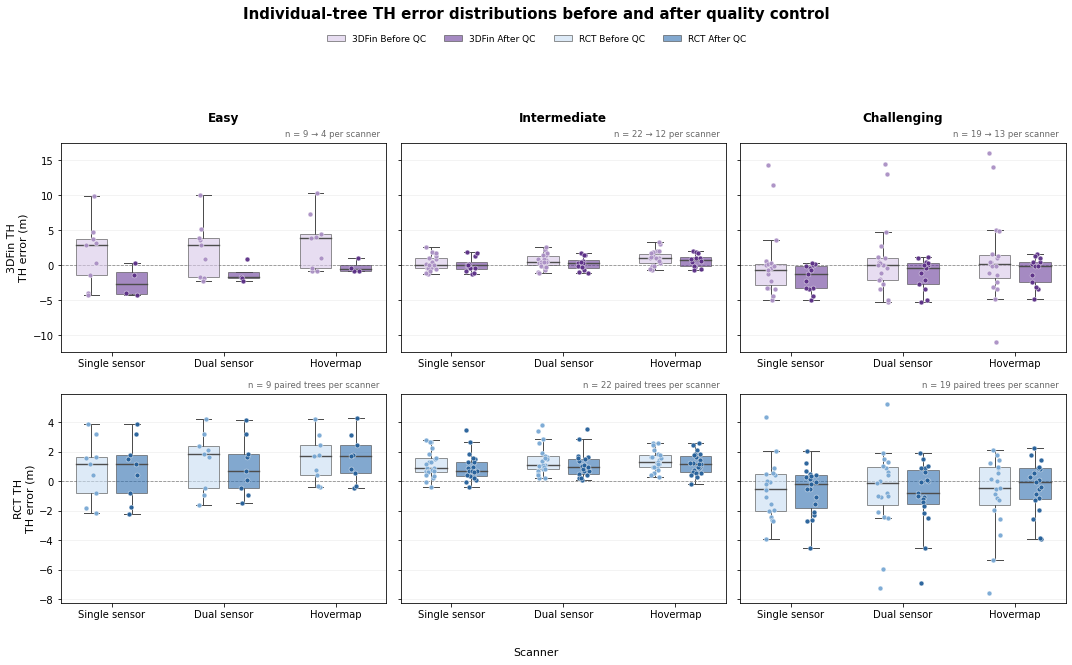

Saved: figure1a_th_before_after.png
Saved: figure1a_th_before_after.pdf


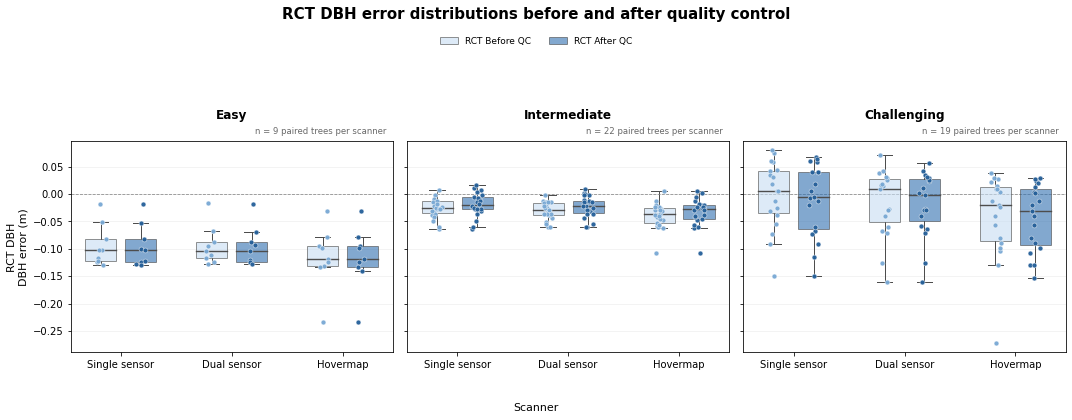

Saved: figure1b_rct_dbh_before_after.png
Saved: figure1b_rct_dbh_before_after.pdf


In [14]:
# Define the terrain, scanner and QC-stage order used throughout
# both Figure 1 plots.
TERRAINS = [
    "Easy",
    "Intermediate",
    "Challenging",
]

SCANNERS = [
    "Single sensor",
    "Dual sensor",
    "Hovermap",
]

DISPLAY_SCANNERS = [
    "Single sensor",
    "Dual sensor",
    "Hovermap",
]

STAGES = [
    "Pre-QC",
    "Post-QC",
]


# Use separate colours for 3DFin and RCT, with lighter shades before QC and darker shades after QC
# Box and point colours differ slightly so the individual observations remain visible
BOX_COLOURS = {
    ("3DFin", "Pre-QC"): "#d8c7e8",
    ("3DFin", "Post-QC"): "#6a3d9a",
    ("RCT", "Pre-QC"): "#c7ddf2",
    ("RCT", "Post-QC"): "#2f6fb0",
}

POINT_COLOURS = {
    ("3DFin", "Pre-QC"): "#aa8fc4",
    ("3DFin", "Post-QC"): "#5b2f86",
    ("RCT", "Pre-QC"): "#78a8d4",
    ("RCT", "Post-QC"): "#245f99",
}

EDGE_COLOUR = "#4d4d4d"


# Place the before- and after-QC distributions side-by-side within each scanner group
stage_offsets = {
    "Pre-QC": -0.18,
    "Post-QC": 0.18,
}


# Fix the random seed so the point jitter is reproducible
rng = np.random.RandomState(42)


# Split the Figure 1 dataset into the final TH and DBH plots
figure1a_data = figure1_data[
    figure1_data["Figure_row"].isin(
        [
            "3DFin TH",
            "RCT TH",
        ]
    )
].copy()


figure1b_data = figure1_data[
    figure1_data["Figure_row"] == "RCT DBH"
].copy()


require(
    len(figure1a_data) == 537,
    "Expected 537 records in Figure 1a.",
)

require(
    len(figure1b_data) == 300,
    "Expected 300 records in Figure 1b.",
)


def get_sample_label(
    panel_df,
    workflow,
    terrain,
    attribute,
):
    """
    Return the sample-size annotation shown above one panel.
    """

    subset = panel_df[
        (panel_df["Workflow"] == workflow)
        &
        (panel_df["Terrain"] == terrain)
        &
        (panel_df["Attribute"] == attribute)
    ]

    counts = (
        subset
        .groupby("QC_stage")
        .size()
        .to_dict()
    )

    # Each GT tree contributes one observation from each of the three scanners, so divide the row counts by three
    pre_n = counts.get(
        "Pre-QC",
        0,
    ) // 3

    post_n = counts.get(
        "Post-QC",
        0,
    ) // 3


    # 3DFin TH uses an exclusion-based comparison, while RCT uses the same paired trees before and after QC
    if workflow == "3DFin":

        return (
            f"n = {pre_n} → {post_n} "
            "per scanner"
        )

    else:

        return (
            f"n = {pre_n} paired trees "
            "per scanner"
        )


def draw_before_after_panel(
    ax,
    panel_df,
    workflow,
    attribute,
    terrain,
    y_label=None,
    show_title=False,
):
    """
    Draw one before/after boxplot panel with jittered tree-level observations.
    """

    subset = panel_df[
        (panel_df["Workflow"] == workflow)
        &
        (panel_df["Attribute"] == attribute)
        &
        (panel_df["Terrain"] == terrain)
    ].copy()


    for scanner_index, scanner in enumerate(SCANNERS):

        base_position = scanner_index + 1


        for stage in STAGES:

            values = (
                subset[
                    (subset["Scanner"] == scanner)
                    &
                    (subset["QC_stage"] == stage)
                ]["Error"]
                .dropna()
                .to_numpy()
            )


            position = (
                base_position
                +
                stage_offsets[stage]
            )


            box_colour = (
                BOX_COLOURS[
                    (workflow, stage)
                ]
            )

            point_colour = (
                POINT_COLOURS[
                    (workflow, stage)
                ]
            )


            # Draw the error distribution without separate outlier markers because every observation is added below
            bp = ax.boxplot(
                [values],
                positions=[position],
                widths=0.28,
                showfliers=False,
                patch_artist=True,
                manage_ticks=False,
            )


            for box in bp["boxes"]:

                box.set_facecolor(
                    box_colour
                )

                box.set_edgecolor(
                    EDGE_COLOUR
                )

                box.set_alpha(0.60)

                box.set_linewidth(1.0)


            for whisker in bp["whiskers"]:

                whisker.set_color(
                    EDGE_COLOUR
                )

                whisker.set_linewidth(1.0)


            for cap in bp["caps"]:

                cap.set_color(
                    EDGE_COLOUR
                )

                cap.set_linewidth(1.0)


            for median in bp["medians"]:

                median.set_color(
                    EDGE_COLOUR
                )

                median.set_linewidth(1.4)


            # Add every tree-level observation with a small amount of horizontal jitter to reduce overlap
            jitter = rng.uniform(
                -0.05,
                0.05,
                size=len(values),
            )


            ax.scatter(
                np.full(
                    len(values),
                    position,
                )
                + jitter,
                values,
                s=24,
                alpha=0.95,
                color=point_colour,
                edgecolors="white",
                linewidths=0.45,
                zorder=3,
            )


    # Add a zero-error reference line so over- and underestimation can be distinguished directly
    ax.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=0.8,
        alpha=0.9,
    )


    # Apply the common scanner labels and light horizontal grid
    ax.set_xticks(
        [1, 2, 3]
    )

    ax.set_xticklabels(
        DISPLAY_SCANNERS,
        rotation=0,
        fontsize=10,
    )


    ax.grid(
        axis="y",
        alpha=0.18,
    )


    if y_label is not None:

        ax.set_ylabel(
            y_label,
            fontsize=11,
        )


    if show_title:

        ax.set_title(
            terrain,
            fontsize=12,
            fontweight="bold",
            pad=22,
        )


    # Place the sample-size label above the plotting area so it does not overlap with large individual-tree errors
    sample_label = get_sample_label(
        panel_df=panel_df,
        workflow=workflow,
        terrain=terrain,
        attribute=attribute,
    )


    ax.text(
        0.98,
        1.025,
        sample_label,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8.5,
        color="dimgray",
        clip_on=False,
    )


# Figure 1a compares 3DFin and RCT TH errors before and after QC across the three terrain conditions
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 9),
    sharey="row",
)


row_specs = [
    (
        "3DFin",
        "TH",
        "3DFin TH\nTH error (m)",
    ),
    (
        "RCT",
        "TH",
        "RCT TH\nTH error (m)",
    ),
]


for row_index, (
    workflow,
    attribute,
    y_label,
) in enumerate(row_specs):

    for col_index, terrain in enumerate(TERRAINS):

        ax = axes[
            row_index,
            col_index
        ]


        draw_before_after_panel(
            ax=ax,
            panel_df=figure1a_data,
            workflow=workflow,
            attribute=attribute,
            terrain=terrain,
            y_label=(
                y_label
                if col_index == 0
                else None
            ),
            show_title=(
                row_index == 0
            ),
        )


# Build a single legend distinguishing workflow and QC stage
legend_handles = [

    Patch(
        facecolor=BOX_COLOURS[
            ("3DFin", "Pre-QC")
        ],
        edgecolor=EDGE_COLOUR,
        label="3DFin Before QC",
        alpha=0.60,
    ),

    Patch(
        facecolor=BOX_COLOURS[
            ("3DFin", "Post-QC")
        ],
        edgecolor=EDGE_COLOUR,
        label="3DFin After QC",
        alpha=0.60,
    ),

    Patch(
        facecolor=BOX_COLOURS[
            ("RCT", "Pre-QC")
        ],
        edgecolor=EDGE_COLOUR,
        label="RCT Before QC",
        alpha=0.60,
    ),

    Patch(
        facecolor=BOX_COLOURS[
            ("RCT", "Post-QC")
        ],
        edgecolor=EDGE_COLOUR,
        label="RCT After QC",
        alpha=0.60,
    ),
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.985),
    fontsize=9,
)


fig.supxlabel(
    "Scanner",
    fontsize=11,
)


fig.suptitle(
    "Individual-tree TH error distributions before and after quality control",
    fontsize=15,
    fontweight="bold",
    y=1.015,
)


fig.tight_layout(
    rect=[
        0,
        0.02,
        1,
        0.91,
    ]
)


# Save Figure 1a in both PNG and PDF formats
figure1a_png = (
    FIGURES_DIR
    / "figure1a_th_before_after.png"
)

figure1a_pdf = (
    FIGURES_DIR
    / "figure1a_th_before_after.pdf"
)


fig.savefig(
    figure1a_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure1a_pdf,
    bbox_inches="tight",
)


plt.show()


print(
    f"Saved: {figure1a_png.name}"
)

print(
    f"Saved: {figure1a_pdf.name}"
)


# Figure 1b shows the corresponding before-and-after QC distributions for RCT DBH
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 5.5),
    sharey=True,
)


for col_index, terrain in enumerate(TERRAINS):

    ax = axes[col_index]


    draw_before_after_panel(
        ax=ax,
        panel_df=figure1b_data,
        workflow="RCT",
        attribute="DBH",
        terrain=terrain,
        y_label=(
            "RCT DBH\nDBH error (m)"
            if col_index == 0
            else None
        ),
        show_title=True,
    )


# Figure 1b only contains RCT, so the legend distinguishes the before- and after-QC distributions
legend_handles = [

    Patch(
        facecolor=BOX_COLOURS[
            ("RCT", "Pre-QC")
        ],
        edgecolor=EDGE_COLOUR,
        label="RCT Before QC",
        alpha=0.60,
    ),

    Patch(
        facecolor=BOX_COLOURS[
            ("RCT", "Post-QC")
        ],
        edgecolor=EDGE_COLOUR,
        label="RCT After QC",
        alpha=0.60,
    ),
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.98),
    fontsize=9,
)


fig.supxlabel(
    "Scanner",
    fontsize=11,
)


fig.suptitle(
    "RCT DBH error distributions before and after quality control",
    fontsize=15,
    fontweight="bold",
    y=1.035,
)


fig.tight_layout(
    rect=[
        0,
        0.04,
        1,
        0.87,
    ]
)


# Save Figure 1b in both PNG and PDF formats
figure1b_png = (
    FIGURES_DIR
    / "figure1b_rct_dbh_before_after.png"
)

figure1b_pdf = (
    FIGURES_DIR
    / "figure1b_rct_dbh_before_after.pdf"
)


fig.savefig(
    figure1b_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure1b_pdf,
    bbox_inches="tight",
)


plt.show()


print(
    f"Saved: {figure1b_png.name}"
)

print(
    f"Saved: {figure1b_pdf.name}"
)

In [15]:
# Check the full range of RCT DBH errors shown in Figure 1b
# This helps confirm that the plotted axis range captures the most extreme individual-tree DBH errors

rct_dbh_errors = figure1b_data["Error"]

print(
    "Overall RCT DBH error range:"
)

print(
    f"Minimum = {rct_dbh_errors.min():.6f} m"
)

print(
    f"Maximum = {rct_dbh_errors.max():.6f} m"
)


# Check whether the largest positive and negative errors differ between terrains or between the pre- and post-QC stages
print(
    "\nRange by terrain and QC stage:\n"
)

print(
    figure1b_data
    .groupby(
        [
            "Terrain",
            "QC_stage",
        ]
    )["Error"]
    .agg(
        ["min", "max"]
    )
)


# Identify the individual observations contributing the largest absolute DBH errors in the figure
print(
    "\nFive largest absolute DBH errors:\n"
)

largest_dbh_errors = (
    figure1b_data
    .assign(
        abs_error_check=lambda x:
        x["Error"].abs()
    )
    .sort_values(
        "abs_error_check",
        ascending=False,
    )
    [
        [
            "Terrain",
            "Scanner",
            "GT_ID",
            "QC_stage",
            "Error",
            "abs_error_check",
        ]
    ]
    .head(5)
)

print(
    largest_dbh_errors.to_string(
        index=False
    )
)

Overall RCT DBH error range:
Minimum = -0.271500 m
Maximum = 0.079400 m

Range by terrain and QC stage:

                          min     max
Terrain      QC_stage                
Challenging  Post-QC  -0.1608  0.0672
             Pre-QC   -0.2715  0.0794
Easy         Post-QC  -0.2344 -0.0184
             Pre-QC   -0.2344 -0.0170
Intermediate Post-QC  -0.1085  0.0158
             Pre-QC   -0.1085  0.0080

Five largest absolute DBH errors:

     Terrain      Scanner  GT_ID QC_stage   Error  abs_error_check
 Challenging     Hovermap     14   Pre-QC -0.2715           0.2715
        Easy     Hovermap      6  Post-QC -0.2344           0.2344
        Easy     Hovermap      6   Pre-QC -0.2344           0.2344
 Challenging  Dual sensor     14   Pre-QC -0.1608           0.1608
 Challenging  Dual sensor     14  Post-QC -0.1608           0.1608


In [16]:
# Build the paired RCT QC-change dataset
# Each row represents one matched tree and attribute, with the change in absolute error calculated from before to after QC
# Negative values indicate that QC reduced the absolute error
# Positive values indicate that the error increased

rct_qc_rows = []


for _, row in rct.iterrows():

    for attribute in ["TH", "DBH"]:

        rct_qc_rows.append({
            "Terrain": row["Terrain"],
            "Scanner": row["Scanner"],
            "GT_ID": int(row["GT_ID"]),
            "segment_id": row["segment_id"],
            "Attribute": attribute,
            "Pre_abs_error":
                row[f"before_{attribute}_abs_error"],
            "Post_abs_error":
                row[f"after_{attribute}_abs_error"],
            "Delta_abs_error":
                row[f"{attribute}_delta_abs_error"],
        })


rct_qc_paired = pd.DataFrame(
    rct_qc_rows
)


# There are 150 matched RCT trees and two attributes, which gives 300 paired tree × attribute records
require(
    len(rct_qc_paired) == 300,
    "Expected 300 paired RCT tree × attribute records.",
)


# Check that the stored change in absolute error matches the difference between the post- and pre-QC values
require(
    np.allclose(
        rct_qc_paired["Delta_abs_error"],
        (
            rct_qc_paired["Post_abs_error"]
            -
            rct_qc_paired["Pre_abs_error"]
        ),
        equal_nan=True,
    ),
    "RCT paired absolute-error changes are inconsistent.",
)


print(
    "Paired RCT QC records:",
    len(rct_qc_paired)
)

print("\nTrees per group:\n")

print(
    rct_qc_paired
    .groupby(
        [
            "Terrain",
            "Scanner",
            "Attribute",
        ]
    )
    .size()
)

Paired RCT QC records: 300

Trees per group:

Terrain       Scanner        Attribute
Challenging   Dual sensor    DBH          19
                             TH           19
              Hovermap       DBH          19
                             TH           19
              Single sensor  DBH          19
                             TH           19
Easy          Dual sensor    DBH           9
                             TH            9
              Hovermap       DBH           9
                             TH            9
              Single sensor  DBH           9
                             TH            9
Intermediate  Dual sensor    DBH          22
                             TH           22
              Hovermap       DBH          22
                             TH           22
              Single sensor  DBH          22
                             TH           22
dtype: int64


In [17]:
# Run the final paired bootstrap for the effect of RCT segmentation QC on absolute measurement error
# Change in absolute error is defined as: post-QC absolute error - pre-QC absolute error
# Negative values therefore indicate an improvement after QC
# Positive values indicate increased error

# One seeded random-number generator is used in a fixed group order so the bootstrap results are exactly reproducible

N_BOOTSTRAP = 5000
BOOTSTRAP_SEED = 42

ATTRIBUTE_ORDER = [
    "TH",
    "DBH",
]

TERRAIN_ORDER = [
    "Easy",
    "Intermediate",
    "Challenging",
]

SCANNER_ORDER = [
    "Single sensor",
    "Dual sensor",
    "Hovermap",
]


rng_bootstrap = np.random.default_rng(
    BOOTSTRAP_SEED
)


bootstrap_rows = []


for attribute in ATTRIBUTE_ORDER:

    for terrain in TERRAIN_ORDER:

        for scanner in SCANNER_ORDER:

            group = rct_qc_paired[
                (rct_qc_paired["Attribute"] == attribute)
                &
                (rct_qc_paired["Terrain"] == terrain)
                &
                (rct_qc_paired["Scanner"] == scanner)
            ].copy()


            values = (
                group["Delta_abs_error"]
                .to_numpy(dtype=float)
            )

            n = len(values)


            # Every terrain × scanner × attribute combination should contain at least one paired tree
            require(
                n > 0,
                (
                    f"No observations found for "
                    f"{terrain} | {scanner} | {attribute}."
                ),
            )


            bootstrap_means = np.empty(
                N_BOOTSTRAP
            )


            # Resample the paired tree-level changes with replacement and store the mean change each time
            for i in range(N_BOOTSTRAP):

                resample = rng_bootstrap.choice(
                    values,
                    size=n,
                    replace=True,
                )

                bootstrap_means[i] = (
                    np.mean(resample)
                )


            mean_change = np.mean(values)

            ci_lower, ci_upper = np.percentile(
                bootstrap_means,
                [2.5, 97.5],
            )


            # A QC effect is treated as clear when the 95% bootstrap confidence interval does not include zero
            ci_excludes_zero = (
                (ci_lower > 0)
                or
                (ci_upper < 0)
            )


            if ci_upper < 0:

                result = "Improved"

            elif ci_lower > 0:

                result = "Worsened"

            else:

                result = "Uncertain"


            bootstrap_rows.append({
                "Terrain": terrain,
                "Scanner": scanner,
                "Attribute": attribute,
                "n": n,
                "Mean_delta_abs_error":
                    mean_change,
                "CI_lower":
                    ci_lower,
                "CI_upper":
                    ci_upper,
                "CI_excludes_zero":
                    ci_excludes_zero,
                "Result":
                    result,
            })


rct_qc_bootstrap = pd.DataFrame(
    bootstrap_rows
)


# Two attributes × three terrains × three scanners gives 18 bootstrap groups
require(
    len(rct_qc_bootstrap) == 18,
    "Expected 18 RCT bootstrap groups.",
)


# Keep only groups where the bootstrap confidence interval excludes zero
confirmed_rct_qc = (
    rct_qc_bootstrap[
        rct_qc_bootstrap[
            "CI_excludes_zero"
        ]
    ]
    .copy()
)


# The reconstructed analysis should reproduce the seven groups with clear evidence of a QC effect
require(
    len(confirmed_rct_qc) == 7,
    (
        "Expected seven confirmed RCT QC-effect groups "
        "from the reconstructed analysis."
    ),
)


print(
    "Confirmed RCT QC-effect groups:",
    len(confirmed_rct_qc)
)

print()

print(
    confirmed_rct_qc[
        [
            "Terrain",
            "Scanner",
            "Attribute",
            "n",
            "Mean_delta_abs_error",
            "CI_lower",
            "CI_upper",
            "Result",
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

Confirmed RCT QC-effect groups: 7

      Terrain      Scanner Attribute   n  Mean_delta_abs_error  CI_lower  CI_upper    Result
         Easy  Dual sensor        TH   9               -0.4372   -1.0269   -0.0202  Improved
         Easy     Hovermap        TH   9                0.0285    0.0053    0.0528  Worsened
 Intermediate  Dual sensor        TH  22               -0.3250   -0.6924   -0.0430  Improved
 Intermediate     Hovermap        TH  22               -0.1806   -0.3630   -0.0329  Improved
 Intermediate  Dual sensor       DBH  22               -0.0064   -0.0122   -0.0015  Improved
 Intermediate     Hovermap       DBH  22               -0.0062   -0.0124   -0.0013  Improved
  Challenging  Dual sensor       DBH  19               -0.0024   -0.0050   -0.0003  Improved


In [18]:
# Assess whether the confirmed RCT QC effects are strongly influenced by a single tree
# This check is only applied to groups whose initial bootstrap 95% confidence interval excluded zero
# For each group, identify the tree with the largest absolute change in error 
# Compare its magnitude with the group mean change

# The leverage ratio is:

#     (|largest individual change in absolute error|)/(|group mean change in absolute error|)

# Larger values indicate that one tree contributes a change that is much larger than the average change

influence_rows = []


for _, group_result in confirmed_rct_qc.iterrows():

    terrain = group_result["Terrain"]
    scanner = group_result["Scanner"]
    attribute = group_result["Attribute"]

    group_mean = (
        group_result[
            "Mean_delta_abs_error"
        ]
    )


    group = rct_qc_paired[
        (rct_qc_paired["Terrain"] == terrain)
        &
        (rct_qc_paired["Scanner"] == scanner)
        &
        (rct_qc_paired["Attribute"] == attribute)
    ].copy()


    # Find the tree with the largest absolute before-to-after change in measurement error
    max_index = (
        group["Delta_abs_error"]
        .abs()
        .idxmax()
    )


    max_row = group.loc[
        max_index
    ]


    max_tree_id = int(
        max_row["GT_ID"]
    )

    max_tree_delta = (
        max_row["Delta_abs_error"]
    )


    # Compare the largest individual change with the average change across the full group
    if group_mean != 0:

        leverage_ratio = (
            abs(max_tree_delta)
            /
            abs(group_mean)
        )

    else:

        leverage_ratio = np.nan


    influence_rows.append({
        "Terrain": terrain,
        "Scanner": scanner,
        "Attribute": attribute,
        "n": len(group),
        "Group_mean_delta":
            group_mean,
        "Max_tree_ID":
            max_tree_id,
        "Max_tree_delta":
            max_tree_delta,
        "Leverage_ratio":
            leverage_ratio,
    })


rct_qc_influence = (
    pd.DataFrame(
        influence_rows
    )
    .sort_values(
        "Leverage_ratio",
        ascending=False,
    )
    .reset_index(drop=True)
)


require(
    len(rct_qc_influence) == 7,
    "Expected influence results for seven confirmed groups.",
)


print(
    rct_qc_influence.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

      Terrain      Scanner Attribute   n  Group_mean_delta  Max_tree_ID  Max_tree_delta  Leverage_ratio
 Intermediate  Dual sensor        TH  22           -0.3250           16         -3.1189          9.5969
 Intermediate     Hovermap        TH  22           -0.1806           15         -1.4533          8.0475
  Challenging  Dual sensor       DBH  19           -0.0024           29         -0.0158          6.5546
 Intermediate     Hovermap       DBH  22           -0.0062           15         -0.0398          6.4335
 Intermediate  Dual sensor       DBH  22           -0.0064           15         -0.0396          6.2051
         Easy  Dual sensor        TH   9           -0.4372           34         -2.3023          5.2660
         Easy     Hovermap        TH   9            0.0285           27          0.0935          3.2794


In [19]:
# Test whether each initially confirmed RCT QC effect remains after removing the tree with the largest individual influence
# For each confirmed group:
# 1. Remove the tree with the largest absolute change in error
# 2. Recalculate the mean change in absolute error
# 3. Repeat the 5,000-resample bootstrap

# The original QC effect is treated as robust when the new 95% confidence interval excludes zero after that tree is removed

# A fresh random-number generator with seed 42 is used for each group so the leave-one-out results are exactly reproducible

loo_rows = []


for _, influence_row in rct_qc_influence.iterrows():

    terrain = influence_row["Terrain"]
    scanner = influence_row["Scanner"]
    attribute = influence_row["Attribute"]

    removed_tree = int(
        influence_row["Max_tree_ID"]
    )


    # Remove the most influential tree identified in the previous step and retain all remaining paired observations
    group = rct_qc_paired[
        (rct_qc_paired["Terrain"] == terrain)
        &
        (rct_qc_paired["Scanner"] == scanner)
        &
        (rct_qc_paired["Attribute"] == attribute)
        &
        (rct_qc_paired["GT_ID"] != removed_tree)
    ].copy()


    values = (
        group["Delta_abs_error"]
        .to_numpy(dtype=float)
    )

    n = len(values)


    # Use a fresh seeded generator for each leave-one-out test
    rng_loo = np.random.default_rng(42)


    bootstrap_means = np.empty(
        N_BOOTSTRAP
    )


    # Bootstrap the mean change in absolute error after removing the most influential tree
    for i in range(N_BOOTSTRAP):

        resample = rng_loo.choice(
            values,
            size=n,
            replace=True,
        )

        bootstrap_means[i] = (
            np.mean(resample)
        )


    loo_mean = np.mean(values)

    loo_ci_lower, loo_ci_upper = np.percentile(
        bootstrap_means,
        [2.5, 97.5],
    )


    # The effect remains clear if the leave-one-out confidence interval still does not include zero
    loo_ci_excludes_zero = (
        (loo_ci_lower > 0)
        or
        (loo_ci_upper < 0)
    )


    if loo_ci_excludes_zero:

        robustness = "Robust"

    else:

        robustness = "Not robust"


    loo_rows.append({
        "Terrain": terrain,
        "Scanner": scanner,
        "Attribute": attribute,
        "Original_n": int(
            influence_row["n"]
        ),
        "Removed_tree": removed_tree,
        "n_after_removal": n,
        "Original_mean":
            influence_row["Group_mean_delta"],
        "LOO_mean":
            loo_mean,
        "LOO_CI_lower":
            loo_ci_lower,
        "LOO_CI_upper":
            loo_ci_upper,
        "LOO_CI_excludes_zero":
            loo_ci_excludes_zero,
        "Robustness":
            robustness,
    })


rct_qc_loo = pd.DataFrame(
    loo_rows
)


require(
    len(rct_qc_loo) == 7,
    "Expected seven leave-one-out robustness tests.",
)


print(
    rct_qc_loo.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)


print(
    "\nRobustness summary:"
)

print(
    rct_qc_loo["Robustness"]
    .value_counts()
)

      Terrain      Scanner Attribute  Original_n  Removed_tree  n_after_removal  Original_mean  LOO_mean  LOO_CI_lower  LOO_CI_upper  LOO_CI_excludes_zero  Robustness
 Intermediate  Dual sensor        TH          22            16               21        -0.3250   -0.1919       -0.4445        0.0040                 False  Not robust
 Intermediate     Hovermap        TH          22            15               21        -0.1806   -0.1200       -0.2634        0.0000                 False  Not robust
  Challenging  Dual sensor       DBH          19            29               18        -0.0024   -0.0017       -0.0038        0.0001                 False  Not robust
 Intermediate     Hovermap       DBH          22            15               21        -0.0062   -0.0046       -0.0098        0.0000                 False  Not robust
 Intermediate  Dual sensor       DBH          22            15               21        -0.0064   -0.0048       -0.0102       -0.0003                  True      Robus

In [20]:
# Save the RCT QC bootstrap results and the two sensitivity checks as separate CSV files for later reporting

bootstrap_output = (
    TABLES_DIR
    / "rct_qc_bootstrap_summary.csv"
)

influence_output = (
    TABLES_DIR
    / "rct_qc_influence_check.csv"
)

loo_output = (
    TABLES_DIR
    / "rct_qc_leave_one_out.csv"
)


rct_qc_bootstrap.to_csv(
    bootstrap_output,
    index=False,
)

rct_qc_influence.to_csv(
    influence_output,
    index=False,
)

rct_qc_loo.to_csv(
    loo_output,
    index=False,
)


print(f"Saved: {bootstrap_output.name}")
print(f"Saved: {influence_output.name}")
print(f"Saved: {loo_output.name}")

Saved: rct_qc_bootstrap_summary.csv
Saved: rct_qc_influence_check.csv
Saved: rct_qc_leave_one_out.csv


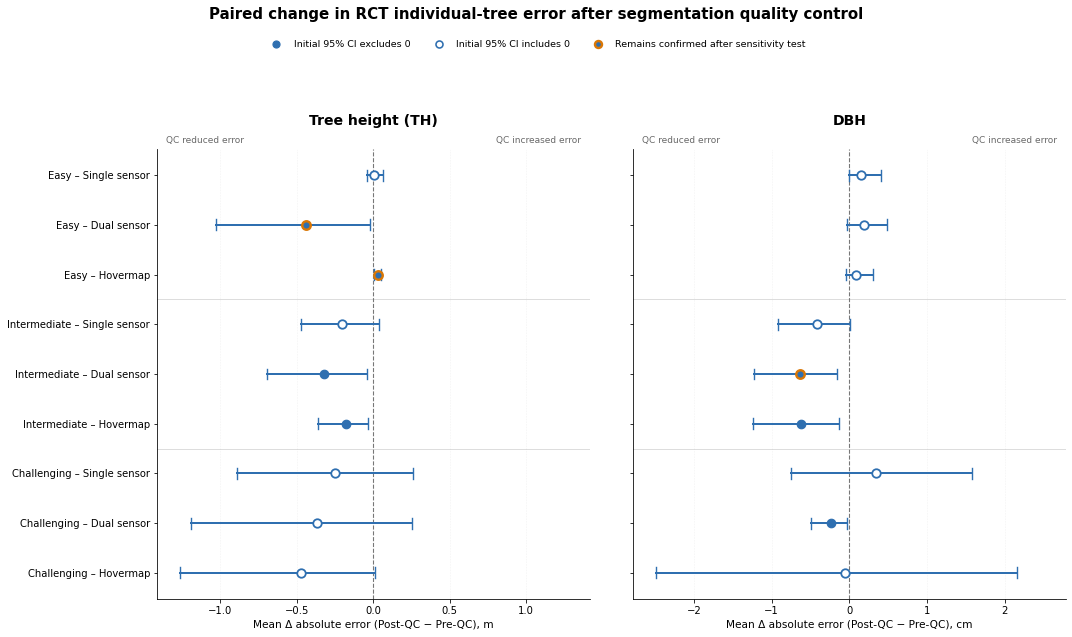

Saved: figure2_rct_qc_paired_change.png
Saved: figure2_rct_qc_paired_change.pdf


In [21]:
# Figure 2 shows the paired effect of RCT segmentation QC on individual-tree absolute error

# The plotted change is: Post-QC |error| - Pre-QC |error|
# Negative values indicate reduced error after QC
# Positive values indicate increased error

# Hollow blue circles show groups whose initial 95% bootstrap CI includes zero
# Filled blue circles show groups whose CI excludes zero
# An orange outline marks effects that also remain confirmed after the leave-one-out sensitivity analysis

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# Define the display order used in both panels
TERRAIN_ORDER = [
    "Easy",
    "Intermediate",
    "Challenging",
]

SCANNER_ORDER = [
    "Single sensor",
    "Dual sensor",
    "Hovermap",
]


# Start with the bootstrap summary calculated above
figure2_data = (
    rct_qc_bootstrap
    .copy()
)


# Add the result of the leave-one-out sensitivity analysis
robustness_lookup = (
    rct_qc_loo[
        [
            "Terrain",
            "Scanner",
            "Attribute",
            "LOO_CI_excludes_zero",
        ]
    ]
    .copy()
)


figure2_data = (
    figure2_data
    .merge(
        robustness_lookup,
        on=[
            "Terrain",
            "Scanner",
            "Attribute",
        ],
        how="left",
    )
)


# Groups without a leave-one-out result were not initially confirmed, so mark their robustness result as False
figure2_data[
    "LOO_CI_excludes_zero"
] = (
    figure2_data[
        "LOO_CI_excludes_zero"
    ]
    .fillna(False)
    .astype(bool)
)


# TH is plotted in metres
# Convert DBH changes from metres to centimetres so the effect sizes are easier to read
figure2_data[
    "Plot_mean"
] = (
    figure2_data[
        "Mean_delta_abs_error"
    ]
)

figure2_data[
    "Plot_CI_lower"
] = (
    figure2_data[
        "CI_lower"
    ]
)

figure2_data[
    "Plot_CI_upper"
] = (
    figure2_data[
        "CI_upper"
    ]
)


dbh_mask = (
    figure2_data["Attribute"]
    == "DBH"
)


figure2_data.loc[
    dbh_mask,
    [
        "Plot_mean",
        "Plot_CI_lower",
        "Plot_CI_upper",
    ]
] = (
    figure2_data.loc[
        dbh_mask,
        [
            "Plot_mean",
            "Plot_CI_lower",
            "Plot_CI_upper",
        ]
    ]
    * 100
)


# Create one row position for each terrain × scanner combination
row_order = []

for terrain in TERRAIN_ORDER:

    for scanner in SCANNER_ORDER:

        row_order.append(
            (
                terrain,
                scanner,
            )
        )


row_positions = {
    combination:
        len(row_order) - 1 - index

    for index, combination
    in enumerate(row_order)
}


figure2_data["y"] = (
    figure2_data.apply(
        lambda row:
        row_positions[
            (
                row["Terrain"],
                row["Scanner"],
            )
        ],
        axis=1,
    )
)


# Use one colour for the RCT estimates 
# Use a contrasting outline for effects that remain confirmed after sensitivity testing
RCT_BLUE = "#2f6fb0"
ROBUST_COLOUR = "#d97706"
ZERO_COLOUR = "#777777"
SEPARATOR_COLOUR = "#d5d5d5"


# Create separate TH and DBH panels with a shared y-axis
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 8.5),
    sharey=True,
)


panel_settings = [
    (
        "TH",
        "Tree height (TH)",
        "Mean Δ absolute error (Post-QC − Pre-QC), m",
    ),
    (
        "DBH",
        "DBH",
        "Mean Δ absolute error (Post-QC − Pre-QC), cm",
    ),
]


for ax, (
    attribute,
    title,
    x_label,
) in zip(
    axes,
    panel_settings,
):

    panel = (
        figure2_data[
            figure2_data["Attribute"]
            == attribute
        ]
        .copy()
    )


    # Draw the point estimate and 95% bootstrap confidence interval for each terrain × scanner combination
    for _, row in panel.iterrows():

        y = row["y"]

        estimate = (
            row["Plot_mean"]
        )

        ci_lower = (
            row["Plot_CI_lower"]
        )

        ci_upper = (
            row["Plot_CI_upper"]
        )


        ax.plot(
            [
                ci_lower,
                ci_upper,
            ],
            [
                y,
                y,
            ],
            color=RCT_BLUE,
            linewidth=2.0,
            zorder=2,
        )


        # Add small end caps to the confidence interval
        cap_height = 0.11

        ax.plot(
            [
                ci_lower,
                ci_lower,
            ],
            [
                y - cap_height,
                y + cap_height,
            ],
            color=RCT_BLUE,
            linewidth=1.4,
            zorder=2,
        )

        ax.plot(
            [
                ci_upper,
                ci_upper,
            ],
            [
                y - cap_height,
                y + cap_height,
            ],
            color=RCT_BLUE,
            linewidth=1.4,
            zorder=2,
        )


        # Use the same point size
        # Indicate the strength and robustness of the QC effect
        if row["CI_excludes_zero"]:

            if row[
                "LOO_CI_excludes_zero"
            ]:

                ax.scatter(
                    estimate,
                    y,
                    s=72,
                    facecolor=RCT_BLUE,
                    edgecolor=ROBUST_COLOUR,
                    linewidth=2.4,
                    zorder=4,
                )

            else:

                ax.scatter(
                    estimate,
                    y,
                    s=72,
                    facecolor=RCT_BLUE,
                    edgecolor=RCT_BLUE,
                    linewidth=1.2,
                    zorder=3,
                )

        else:

            ax.scatter(
                estimate,
                y,
                s=72,
                facecolor="white",
                edgecolor=RCT_BLUE,
                linewidth=1.8,
                zorder=3,
            )


    # Zero represents no change in absolute error after QC
    ax.axvline(
        0,
        color=ZERO_COLOUR,
        linestyle="--",
        linewidth=1.1,
        zorder=1,
    )


    # Keep each panel symmetric around zero so improvements and increases in error can be compared directly
    max_extent = max(
        abs(
            panel[
                "Plot_CI_lower"
            ].min()
        ),
        abs(
            panel[
                "Plot_CI_upper"
            ].max()
        ),
    )

    x_limit = (
        max_extent
        * 1.12
    )

    ax.set_xlim(
        -x_limit,
        x_limit,
    )


    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=24,
    )

    ax.set_xlabel(
        x_label,
        fontsize=10.5,
    )


    # Add a simple guide showing the direction of the QC effect
    ax.text(
        0.02,
        1.01,
        "QC reduced error",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=9,
        color="dimgray",
    )

    ax.text(
        0.98,
        1.01,
        "QC increased error",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        color="dimgray",
    )


    # Apply light grid lines and remove unnecessary borders
    ax.grid(
        axis="x",
        linestyle=":",
        linewidth=0.6,
        alpha=0.25,
    )

    ax.set_axisbelow(True)

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )


# Label each terrain × scanner row on the shared y-axis
y_ticks = []
y_labels = []


for terrain, scanner in row_order:

    y_ticks.append(
        row_positions[
            (
                terrain,
                scanner,
            )
        ]
    )

    y_labels.append(
        f"{terrain} – {scanner}"
    )


axes[0].set_yticks(
    y_ticks
)

axes[0].set_yticklabels(
    y_labels,
    fontsize=10,
)


# Separate the three terrain groups visually
separator_positions = [
    5.5,
    2.5,
]


for ax in axes:

    for separator in separator_positions:

        ax.axhline(
            separator,
            color=SEPARATOR_COLOUR,
            linewidth=0.8,
            zorder=0,
        )


# Explain the three point styles used to show initial and leave-one-out bootstrap results
legend_handles = [

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=RCT_BLUE,
        markeredgecolor=RCT_BLUE,
        markeredgewidth=1.2,
        markersize=7,
        label="Initial 95% CI excludes 0",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=RCT_BLUE,
        markeredgewidth=1.6,
        markersize=7,
        label="Initial 95% CI includes 0",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=RCT_BLUE,
        markeredgecolor=ROBUST_COLOUR,
        markeredgewidth=2.4,
        markersize=7,
        label="Remains confirmed after sensitivity test",
    ),
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        0.995,
    ),
    ncol=3,
    frameon=False,
    fontsize=9.5,
)


fig.suptitle(
    "Paired change in RCT individual-tree error after segmentation quality control",
    fontsize=15,
    fontweight="bold",
    y=1.035,
)


fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.92,
    ],
    w_pad=4,
)


# Save Figure 2 in both PNG and PDF formats
figure2_png = (
    FIGURES_DIR
    / "figure2_rct_qc_paired_change.png"
)

figure2_pdf = (
    FIGURES_DIR
    / "figure2_rct_qc_paired_change.pdf"
)


fig.savefig(
    figure2_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure2_pdf,
    bbox_inches="tight",
)


plt.show()


print(
    f"Saved: {figure2_png.name}"
)

print(
    f"Saved: {figure2_pdf.name}"
)

In [22]:
# Build the final strict post-QC common-tree sample and calculate descriptive performance metrics
# A GT tree is retained only when it has all six observations (3 scanners × 2 workflows) within the same terrain and attribute
# This ensures that 3DFin and RCT are compared using the same physical trees
# Keep only the final post-QC measurements

postqc = (
    analysis_long[
        analysis_long["QC_stage"] == "Post-QC"
    ]
    .copy()
)


# Check how completely each GT tree is represented across scanners and workflows within each terrain and attribute
tree_coverage = (
    postqc
    .groupby(
        [
            "Terrain",
            "Attribute",
            "GT_ID",
        ]
    )
    .agg(
        n_rows=("Workflow", "size"),
        n_workflows=("Workflow", "nunique"),
        n_scanners=("Scanner", "nunique"),
    )
    .reset_index()
)


# Retain only trees with all three scanners in both workflows
eligible_trees = (
    tree_coverage[
        (tree_coverage["n_rows"] == 6)
        &
        (tree_coverage["n_workflows"] == 2)
        &
        (tree_coverage["n_scanners"] == 3)
    ]
    [
        [
            "Terrain",
            "Attribute",
            "GT_ID",
        ]
    ]
    .copy()
)


# Create the final strict common-tree dataset
final_common = (
    postqc
    .merge(
        eligible_trees,
        on=[
            "Terrain",
            "Attribute",
            "GT_ID",
        ],
        how="inner",
    )
    .copy()
)


# Check the expected total sample size 
# Confirm that there is only one observation per terrain, workflow, scanner, tree and attribute combination
require(
    len(final_common) == 462,
    (
        "Expected 462 observations in the strict "
        "post-QC common-tree sample."
    ),
)


require(
    final_common[
        [
            "Terrain",
            "Workflow",
            "Scanner",
            "GT_ID",
            "Attribute",
        ]
    ]
    .duplicated()
    .sum()
    == 0,
    "Duplicate observations found in final_common.",
)


# Summarise the number of unique GT trees retained for each terrain and attribute
common_tree_counts = (
    final_common
    .groupby(
        [
            "Terrain",
            "Attribute",
        ]
    )["GT_ID"]
    .nunique()
    .unstack()
)


print("Common GT trees:\n")

print(
    common_tree_counts
)

print(
    "\nTotal observations:",
    len(final_common),
)


def prediction_r2(
    reference,
    predicted,
):
    """
    Calculate prediction-style R² as 1 - SSE / SST.
    This measures how closely the scanner predictions agree with the field-reference values.
    """

    reference = np.asarray(
        reference,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )


    sse = np.sum(
        (
            predicted
            - reference
        ) ** 2
    )


    sst = np.sum(
        (
            reference
            - np.mean(reference)
        ) ** 2
    )


    if sst == 0:
        return np.nan


    return (
        1
        -
        sse / sst
    )


# Calculate RMSE, MAE, Bias and prediction-style R² for each terrain × workflow × scanner × attribute combination
performance_rows = []


for (
    terrain,
    workflow,
    scanner,
    attribute,
), group in final_common.groupby(
    [
        "Terrain",
        "Workflow",
        "Scanner",
        "Attribute",
    ]
):

    reference = (
        group["GT_value"]
        .to_numpy(
            dtype=float
        )
    )

    predicted = (
        group["Predicted_value"]
        .to_numpy(
            dtype=float
        )
    )

    error = (
        predicted
        - reference
    )


    performance_rows.append(
        {
            "Terrain": terrain,
            "Workflow": workflow,
            "Scanner": scanner,
            "Attribute": attribute,
            "n": len(group),

            "RMSE": np.sqrt(
                np.mean(
                    error ** 2
                )
            ),

            "MAE": np.mean(
                np.abs(error)
            ),

            "Bias": np.mean(
                error
            ),

            "R2": prediction_r2(
                reference,
                predicted,
            ),
        }
    )


final_common_metrics = (
    pd.DataFrame(
        performance_rows
    )
)


# Three terrains × two workflows × three scanners × two attributes gives 36 final summary rows
require(
    len(final_common_metrics) == 36,
    "Expected 36 Terrain × Workflow × Scanner × Attribute rows.",
)


# Define a consistent display order for the final results table
terrain_order_map = {
    "Easy": 0,
    "Intermediate": 1,
    "Challenging": 2,
}

attribute_order_map = {
    "TH": 0,
    "DBH": 1,
}

workflow_order_map = {
    "3DFin": 0,
    "RCT": 1,
}

scanner_order_map = {
    "Single sensor": 0,
    "Dual sensor": 1,
    "Hovermap": 2,
}


final_common_metrics[
    "_terrain"
] = (
    final_common_metrics[
        "Terrain"
    ]
    .map(
        terrain_order_map
    )
)

final_common_metrics[
    "_attribute"
] = (
    final_common_metrics[
        "Attribute"
    ]
    .map(
        attribute_order_map
    )
)

final_common_metrics[
    "_workflow"
] = (
    final_common_metrics[
        "Workflow"
    ]
    .map(
        workflow_order_map
    )
)

final_common_metrics[
    "_scanner"
] = (
    final_common_metrics[
        "Scanner"
    ]
    .map(
        scanner_order_map
    )
)


final_common_metrics = (
    final_common_metrics
    .sort_values(
        [
            "_attribute",
            "_terrain",
            "_workflow",
            "_scanner",
        ]
    )
    .drop(
        columns=[
            "_terrain",
            "_attribute",
            "_workflow",
            "_scanner",
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nFinal common-sample performance metrics:\n"
)

print(
    final_common_metrics.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

Common GT trees:

Attribute     DBH  TH
Terrain              
Challenging    18  13
Easy            9   4
Intermediate   21  12

Total observations: 462

Final common-sample performance metrics:

      Terrain Workflow        Scanner Attribute   n   RMSE    MAE    Bias      R2
         Easy    3DFin  Single sensor        TH   4 3.0330 2.5188 -2.3750 -2.4552
         Easy    3DFin    Dual sensor        TH   4 1.7213 1.6413 -1.2315 -0.1129
         Easy    3DFin       Hovermap        TH   4 0.8196 0.7878 -0.2685  0.7477
         Easy      RCT  Single sensor        TH   4 1.5671 1.4690 -0.8901  0.0776
         Easy      RCT    Dual sensor        TH   4 1.2213 1.1249 -0.3039  0.4397
         Easy      RCT       Hovermap        TH   4 0.9782 0.7781  0.3894  0.6406
 Intermediate    3DFin  Single sensor        TH  12 0.9879 0.7630  0.0638  0.5754
 Intermediate    3DFin    Dual sensor        TH  12 0.9202 0.7684  0.2108  0.6317
 Intermediate    3DFin       Hovermap        TH  12 1.1030 0.9235 

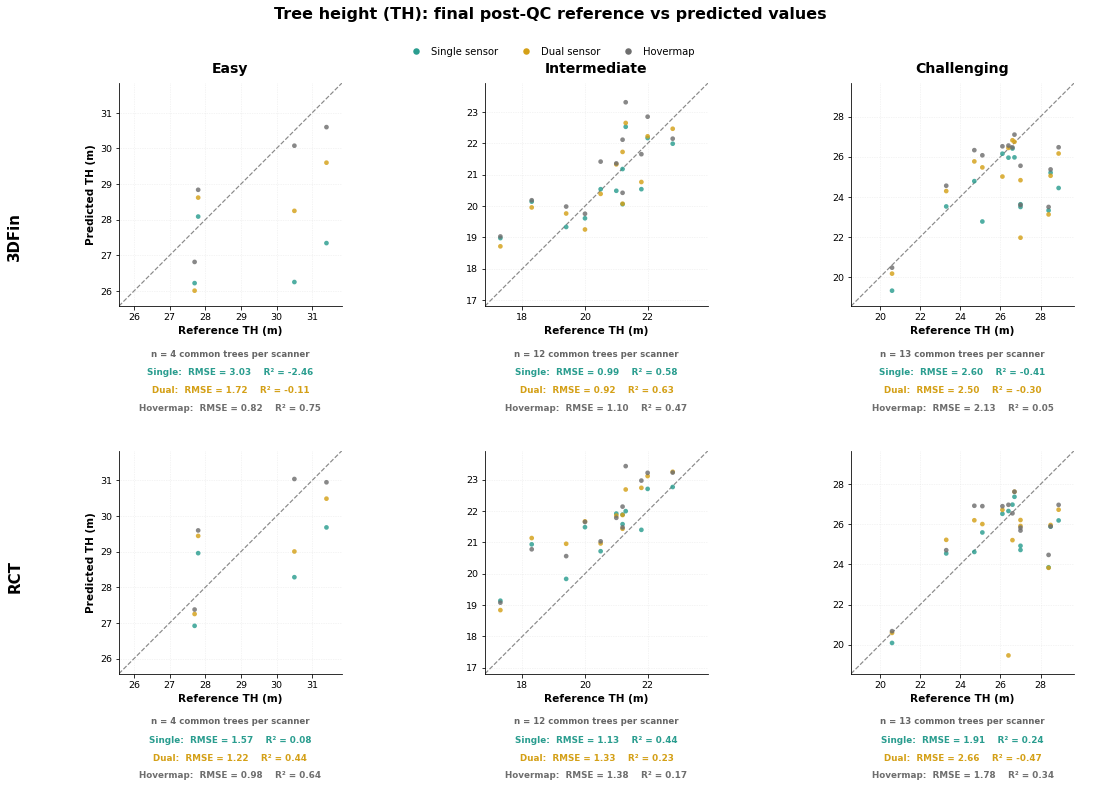

Saved: figure3_th_reference_vs_predicted.png
Saved: figure3_th_reference_vs_predicted.pdf


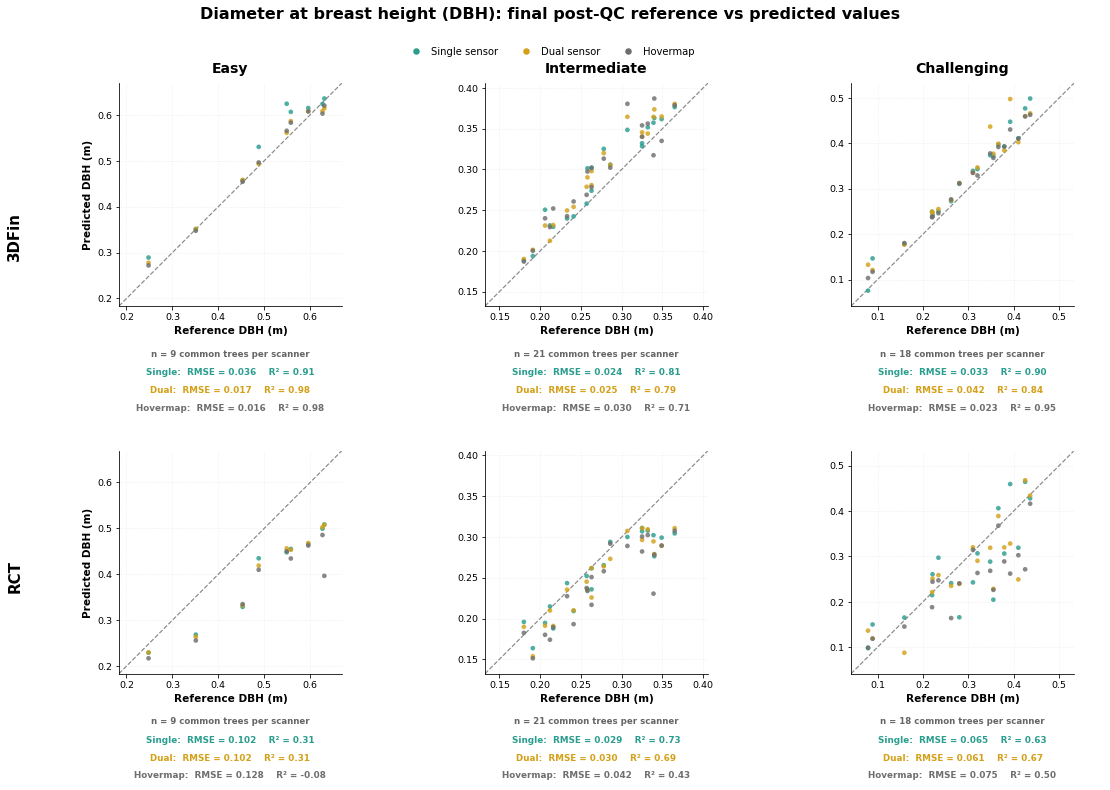

Saved: figure3_dbh_reference_vs_predicted.png
Saved: figure3_dbh_reference_vs_predicted.pdf


In [23]:
# Figures 3A and 3B show the final post-QC agreement between field-reference and predicted values
# Figure 3A shows TH and Figure 3B shows DBH
# Each figure contains six scatter panels for Easy, Intermediate and Challenging terrains x 3DFin, RCT workflows
# A separate statistics strip is placed below each scatter panel so the summary values do not overlap with the observations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec


# Check that the common-tree dataset, performance metrics and figure-output folder have already been created
if "final_common" not in globals():
    raise NameError(
        "final_common is not defined. "
        "Please run the final common-tree cell first."
    )

if "final_common_metrics" not in globals():
    raise NameError(
        "final_common_metrics is not defined. "
        "Please run the final metrics cell first."
    )

if "FIGURES_DIR" not in globals():
    raise NameError(
        "FIGURES_DIR is not defined."
    )


# Define the display order used throughout both figures
TERRAIN_ORDER = [
    "Easy",
    "Intermediate",
    "Challenging",
]

WORKFLOW_ORDER = [
    "3DFin",
    "RCT",
]

SCANNER_ORDER = [
    "Single sensor",
    "Dual sensor",
    "Hovermap",
]

SCANNER_SHORT = {
    "Single sensor": "Single",
    "Dual sensor": "Dual",
    "Hovermap": "Hovermap",
}

ATTRIBUTE_TITLES = {
    "TH": "Tree height (TH)",
    "DBH": "Diameter at breast height (DBH)",
}

ATTRIBUTE_UNITS = {
    "TH": "m",
    "DBH": "m",
}


# Use one colour for each scanner
# The same colours are used for the observations and the corresponding statistics below each panel
SCANNER_COLOURS = {
    "Single sensor": "#2A9D8F",
    "Dual sensor":   "#D4A017",
    "Hovermap":      "#6E6E6E",
}

ONE_TO_ONE_COLOUR = "#8A8A8A"
GRID_COLOUR = "#E1E1E1"
STATS_GREY = "#666666"


def metric_precision(attribute):
    """
    Return the number of decimal places used to display RMSE.
    """

    if attribute == "TH":
        return 2

    return 3


def format_metric(value, digits):
    """
    Format one metric value for the figure annotation.
    """

    if pd.isna(value):
        return "NA"

    return f"{value:.{digits}f}"


def get_panel_limits(
    data,
    attribute,
    terrain,
):
    """
    Return common x- and y-axis limits for both workflows within
    one terrain and attribute.
    Using the same limits makes the 3DFin and RCT panels directly comparable.
    """

    subset = data[
        (data["Attribute"] == attribute)
        &
        (data["Terrain"] == terrain)
    ].copy()


    values = pd.concat(
        [
            subset["GT_value"],
            subset["Predicted_value"],
        ],
        ignore_index=True,
    ).astype(float)


    data_min = values.min()
    data_max = values.max()

    data_range = (
        data_max
        - data_min
    )


    if data_range == 0:

        padding = 1.0

    else:

        padding = (
            0.08
            * data_range
        )


    return (
        data_min - padding,
        data_max + padding,
    )


def draw_stats_strip(
    ax,
    terrain,
    workflow,
    attribute,
):
    """
    Draw the sample size and scanner-level performance statistics below one scatter panel.
    """

    ax.axis("off")


    metrics_panel = final_common_metrics[
        (final_common_metrics["Terrain"] == terrain)
        &
        (final_common_metrics["Workflow"] == workflow)
        &
        (final_common_metrics["Attribute"] == attribute)
    ].copy()


    digits = metric_precision(
        attribute
    )


    # All three scanners use the same number of trees because the figure is based on the strict common-tree sample
    panel_n = int(
        metrics_panel["n"].iloc[0]
    )


    ax.text(
        0.5,
        0.83,
        f"n = {panel_n} common trees per scanner",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=8.6,
        fontweight="semibold",
        color=STATS_GREY,
    )


    # Display the RMSE and R² for each scanner on a separate line
    y_positions = [
        0.58,
        0.34,
        0.10,
    ]


    for y, scanner in zip(
        y_positions,
        SCANNER_ORDER,
    ):

        row = metrics_panel[
            metrics_panel["Scanner"]
            == scanner
        ]


        require(
            len(row) == 1,
            (
                f"Expected one metrics row for "
                f"{terrain} | {workflow} | "
                f"{attribute} | {scanner}."
            ),
        )


        row = row.iloc[0]


        stats_text = (
            f"{SCANNER_SHORT[scanner]}:  "
            f"RMSE = "
            f"{format_metric(row['RMSE'], digits)}"
            f"    "
            f"R² = "
            f"{format_metric(row['R2'], 2)}"
        )


        ax.text(
            0.5,
            y,
            stats_text,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=8.8,
            fontweight="semibold",
            color=SCANNER_COLOURS[scanner],
        )


def make_attribute_figure(
    attribute,
):
    """
    Create the six-panel reference-versus-predicted figure for one tree attribute.
    """

    attribute_title = (
        ATTRIBUTE_TITLES[
            attribute
        ]
    )

    unit = (
        ATTRIBUTE_UNITS[
            attribute
        ]
    )


    # Use separate rows for the statistics beneath each workflow's scatterplots
    # Row 0 = 3DFin scatterplots
    # Row 1 = 3DFin statistics
    # Row 2 = RCT scatterplots
    # Row 3 = RCT statistics
    
    fig = plt.figure(
        figsize=(16, 11.5)
    )


    gs = GridSpec(
        nrows=4,
        ncols=3,
        figure=fig,
        height_ratios=[
            1.00,
            0.33,
            1.00,
            0.33,
        ],
        hspace=0.24,
        wspace=0.30,
    )


    # Draw one panel for each terrain and workflow
    for col_idx, terrain in enumerate(
        TERRAIN_ORDER
    ):

        lower, upper = get_panel_limits(
            final_common,
            attribute,
            terrain,
        )


        for workflow in WORKFLOW_ORDER:


            if workflow == "3DFin":

                plot_row = 0
                stats_row = 1

            else:

                plot_row = 2
                stats_row = 3


            ax = fig.add_subplot(
                gs[
                    plot_row,
                    col_idx,
                ]
            )


            panel_data = final_common[
                (final_common["Terrain"] == terrain)
                &
                (final_common["Workflow"] == workflow)
                &
                (final_common["Attribute"] == attribute)
            ].copy()


            # Add the 1:1 line representing perfect agreement between the predicted and reference values
            ax.plot(
                [
                    lower,
                    upper,
                ],
                [
                    lower,
                    upper,
                ],
                linestyle="--",
                linewidth=1.2,
                color=ONE_TO_ONE_COLOUR,
                zorder=1,
            )


            # Plot the individual-tree measurements for each scanner
            # Points are kept small because several scanner estimates lie very close together
            for scanner in SCANNER_ORDER:

                scanner_data = panel_data[
                    panel_data["Scanner"]
                    == scanner
                ]


                ax.scatter(
                    scanner_data[
                        "GT_value"
                    ],
                    scanner_data[
                        "Predicted_value"
                    ],
                    s=22,
                    marker="o",
                    facecolor=(
                        SCANNER_COLOURS[
                            scanner
                        ]
                    ),
                    edgecolor="none",
                    alpha=0.82,
                    zorder=3,
                )


            # Use identical x and y limits so distance from the 1:1 line can be interpreted consistently
            ax.set_xlim(
                lower,
                upper,
            )

            ax.set_ylim(
                lower,
                upper,
            )

            ax.set_aspect(
                "equal",
                adjustable="box",
            )


            ax.grid(
                True,
                linestyle=":",
                linewidth=0.65,
                color=GRID_COLOUR,
                alpha=0.8,
            )

            ax.set_axisbelow(
                True
            )


            ax.spines[
                "top"
            ].set_visible(
                False
            )

            ax.spines[
                "right"
            ].set_visible(
                False
            )


            # Show the terrain titles only above the upper row
            if workflow == "3DFin":

                ax.set_title(
                    terrain,
                    fontsize=14,
                    fontweight="bold",
                    pad=10,
                )


            ax.set_xlabel(
                f"Reference {attribute} ({unit})",
                fontsize=10.5,
                fontweight="semibold",
            )


            if col_idx == 0:

                ax.set_ylabel(
                    f"Predicted {attribute} ({unit})",
                    fontsize=10.5,
                    fontweight="semibold",
                )


            ax.tick_params(
                axis="both",
                labelsize=9.5,
            )


            # Add the statistics strip directly below the corresponding scatter panel
            stats_ax = fig.add_subplot(
                gs[
                    stats_row,
                    col_idx,
                ]
            )


            draw_stats_strip(
                ax=stats_ax,
                terrain=terrain,
                workflow=workflow,
                attribute=attribute,
            )


    # Add vertical labels identifying the two workflow rows
    fig.text(
        0.035,
        0.715,
        "3DFin",
        rotation=90,
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
    )


    fig.text(
        0.035,
        0.305,
        "RCT",
        rotation=90,
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
    )


    # Build a shared scanner legend for the figure
    legend_handles = []


    for scanner in SCANNER_ORDER:

        legend_handles.append(

            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor=(
                    SCANNER_COLOURS[
                        scanner
                    ]
                ),
                markeredgecolor="none",
                markersize=6.5,
                label=scanner,
            )

        )


    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            0.955,
        ),
        ncol=3,
        frameon=False,
        fontsize=10,
        handletextpad=0.5,
        columnspacing=1.8,
    )


    fig.suptitle(
        (
            f"{attribute_title}: "
            "final post-QC reference vs predicted values"
        ),
        fontsize=16,
        fontweight="bold",
        y=0.992,
    )


    fig.subplots_adjust(
        left=0.10,
        right=0.98,
        bottom=0.055,
        top=0.90,
    )


    # Save the figure in both PNG and PDF formats
    safe_name = (
        attribute.lower()
    )


    png_path = (
        FIGURES_DIR
        /
        (
            f"figure3_{safe_name}_"
            "reference_vs_predicted.png"
        )
    )


    pdf_path = (
        FIGURES_DIR
        /
        (
            f"figure3_{safe_name}_"
            "reference_vs_predicted.pdf"
        )
    )


    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )


    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )


    plt.show()


    print(
        f"Saved: {png_path.name}"
    )

    print(
        f"Saved: {pdf_path.name}"
    )


# Generate the TH and DBH figures
make_attribute_figure(
    "TH"
)

make_attribute_figure(
    "DBH"
)

In [24]:
# Put the two workflow errors side-by-side for each common tree × scanner × attribute combination
# set_index() + unstack() is used instead of pivot()

workflow_pairs = (
    final_common
    .set_index(
        [
            "Terrain",
            "Attribute",
            "Scanner",
            "GT_ID",
            "Workflow",
        ]
    )["Error"]
    .unstack("Workflow")
    .reset_index()
)


workflow_pairs.columns.name = None


# Check that every retained record contains both a 3DFin and an RCT error value
require(
    "3DFin" in workflow_pairs.columns
    and
    "RCT" in workflow_pairs.columns,
    "Expected separate 3DFin and RCT error columns.",
)


require(
    workflow_pairs[
        [
            "3DFin",
            "RCT",
        ]
    ]
    .notna()
    .all()
    .all(),
    "At least one common-tree record is missing a workflow.",
)


# There should be one paired workflow record for each retained tree × scanner × attribute combination
require(
    len(workflow_pairs) == 231,
    (
        "Expected 231 paired tree × scanner × attribute "
        "records."
    ),
)


print(
    "Paired workflow records:",
    len(workflow_pairs)
)


print(
    "\nPaired trees per Terrain × Scanner × Attribute:\n"
)


print(
    workflow_pairs
    .groupby(
        [
            "Attribute",
            "Terrain",
            "Scanner",
        ]
    )
    .size()
)

Paired workflow records: 231

Paired trees per Terrain × Scanner × Attribute:

Attribute  Terrain       Scanner      
DBH        Challenging   Dual sensor      18
                         Hovermap         18
                         Single sensor    18
           Easy          Dual sensor       9
                         Hovermap          9
                         Single sensor     9
           Intermediate  Dual sensor      21
                         Hovermap         21
                         Single sensor    21
TH         Challenging   Dual sensor      13
                         Hovermap         13
                         Single sensor    13
           Easy          Dual sensor       4
                         Hovermap          4
                         Single sensor     4
           Intermediate  Dual sensor      12
                         Hovermap         12
                         Single sensor    12
dtype: int64


In [25]:
# Run a paired bootstrap to compare 3DFin and RCT RMSE directly
# The comparison is defined as: RMSE_RCT - RMSE_3DFin
# Positive values indicate lower RMSE for 3DFin
# Negative values indicate lower RMSE for RCT
# The same resampled tree positions are used for both workflows so the pairing between 3DFin and RCT measurements is preserved

N_BOOTSTRAP_WORKFLOW = 5000
WORKFLOW_BOOTSTRAP_SEED = 42


ATTRIBUTE_ORDER = [
    "TH",
    "DBH",
]

TERRAIN_ORDER = [
    "Easy",
    "Intermediate",
    "Challenging",
]

SCANNER_ORDER = [
    "Single sensor",
    "Dual sensor",
    "Hovermap",
]


# Expected strict common-tree sample sizes for each terrain and attribute
EXPECTED_N = {
    ("TH", "Easy"): 4,
    ("TH", "Intermediate"): 12,
    ("TH", "Challenging"): 13,
    ("DBH", "Easy"): 9,
    ("DBH", "Intermediate"): 21,
    ("DBH", "Challenging"): 18,
}


# Use one seeded generator across all groups so the full bootstrap analysis is reproducible
rng_workflow = np.random.default_rng(
    WORKFLOW_BOOTSTRAP_SEED
)


summary_rows = []
draw_rows = []


for attribute in ATTRIBUTE_ORDER:

    for terrain in TERRAIN_ORDER:

        for scanner in SCANNER_ORDER:

            group = workflow_pairs[
                (workflow_pairs["Attribute"] == attribute)
                &
                (workflow_pairs["Terrain"] == terrain)
                &
                (workflow_pairs["Scanner"] == scanner)
            ].copy()


            dfin_error = (
                group["3DFin"]
                .to_numpy(dtype=float)
            )

            rct_error = (
                group["RCT"]
                .to_numpy(dtype=float)
            )


            n = len(group)


            # Check that each group contains the expected number of common trees
            require(
                n == EXPECTED_N[
                    (attribute, terrain)
                ],
                (
                    f"Unexpected n for "
                    f"{attribute} | {terrain} | {scanner}. "
                    f"Found {n}."
                ),
            )


            # Calculate the observed RMSE for both workflows
            rmse_3dfin = np.sqrt(
                np.mean(
                    dfin_error ** 2
                )
            )


            rmse_rct = np.sqrt(
                np.mean(
                    rct_error ** 2
                )
            )


            observed_delta = (
                rmse_rct
                - rmse_3dfin
            )


            # Bootstrap the paired difference in RMSE
            bootstrap_delta = np.empty(
                N_BOOTSTRAP_WORKFLOW
            )


            for bootstrap_i in range(
                N_BOOTSTRAP_WORKFLOW
            ):

                # Resample tree positions once and apply the same positions to both workflow error arrays
                sample_indices = (
                    rng_workflow.integers(
                        0,
                        n,
                        size=n,
                    )
                )


                boot_3dfin = (
                    dfin_error[
                        sample_indices
                    ]
                )

                boot_rct = (
                    rct_error[
                        sample_indices
                    ]
                )


                boot_rmse_3dfin = np.sqrt(
                    np.mean(
                        boot_3dfin ** 2
                    )
                )


                boot_rmse_rct = np.sqrt(
                    np.mean(
                        boot_rct ** 2
                    )
                )


                bootstrap_delta[
                    bootstrap_i
                ] = (
                    boot_rmse_rct
                    - boot_rmse_3dfin
                )


            # Use the 2.5th and 97.5th percentiles as the bootstrap 95% confidence interval
            ci_lower, ci_upper = np.percentile(
                bootstrap_delta,
                [
                    2.5,
                    97.5,
                ],
            )


            ci_excludes_zero = (
                (ci_lower > 0)
                or
                (ci_upper < 0)
            )


            if ci_lower > 0:

                interpretation = (
                    "3DFin lower RMSE"
                )

            elif ci_upper < 0:

                interpretation = (
                    "RCT lower RMSE"
                )

            else:

                interpretation = (
                    "Uncertain"
                )


            # Store the observed comparison and bootstrap interval for each terrain × scanner × attribute group
            summary_rows.append(
                {
                    "Terrain": terrain,
                    "Scanner": scanner,
                    "Attribute": attribute,
                    "n": n,
                    "RMSE_3DFin":
                        rmse_3dfin,
                    "RMSE_RCT":
                        rmse_rct,
                    "Delta_RMSE_RCT_minus_3DFin":
                        observed_delta,
                    "CI_lower":
                        ci_lower,
                    "CI_upper":
                        ci_upper,
                    "CI_excludes_zero":
                        ci_excludes_zero,
                    "Interpretation":
                        interpretation,
                }
            )


            # Keep every bootstrap draw so the full distribution remains available for later plotting or checks
            for bootstrap_i, value in enumerate(
                bootstrap_delta,
                start=1,
            ):

                draw_rows.append(
                    {
                        "Terrain": terrain,
                        "Scanner": scanner,
                        "Attribute": attribute,
                        "Bootstrap_iteration":
                            bootstrap_i,
                        "Delta_RMSE_RCT_minus_3DFin":
                            value,
                    }
                )


workflow_rmse_bootstrap = pd.DataFrame(
    summary_rows
)


workflow_rmse_draws = pd.DataFrame(
    draw_rows
)


# Check the expected number of comparison groups and bootstrap draws
require(
    len(workflow_rmse_bootstrap) == 18,
    "Expected 18 workflow-comparison groups.",
)


require(
    len(workflow_rmse_draws)
    == 18 * N_BOOTSTRAP_WORKFLOW,
    "Expected 90,000 bootstrap draws.",
)


# Confirm that all main bootstrap results were calculated successfully
require(
    workflow_rmse_bootstrap[
        [
            "RMSE_3DFin",
            "RMSE_RCT",
            "Delta_RMSE_RCT_minus_3DFin",
            "CI_lower",
            "CI_upper",
        ]
    ]
    .notna()
    .all()
    .all(),
    "Missing values found in workflow bootstrap results.",
)


print(
    "Bootstrap groups:",
    len(workflow_rmse_bootstrap)
)

print(
    "Bootstrap draws:",
    len(workflow_rmse_draws)
)


print(
    "\nWorkflow RMSE comparison:\n"
)


print(
    workflow_rmse_bootstrap
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

Bootstrap groups: 18
Bootstrap draws: 90000

Workflow RMSE comparison:

      Terrain        Scanner Attribute   n  RMSE_3DFin  RMSE_RCT  Delta_RMSE_RCT_minus_3DFin  CI_lower  CI_upper  CI_excludes_zero    Interpretation
         Easy  Single sensor        TH   4      3.0330    1.5671                     -1.4659   -2.1707   -0.0786              True    RCT lower RMSE
         Easy    Dual sensor        TH   4      1.7213    1.2213                     -0.5000   -1.0277    0.3351             False         Uncertain
         Easy       Hovermap        TH   4      0.8196    0.9782                      0.1585   -0.4511    0.5871             False         Uncertain
 Intermediate  Single sensor        TH  12      0.9879    1.1321                      0.1442   -0.2380    0.4423             False         Uncertain
 Intermediate    Dual sensor        TH  12      0.9202    1.3334                      0.4132    0.0577    0.7130              True  3DFin lower RMSE
 Intermediate       Hovermap      

In [26]:
# Save the workflow-comparison bootstrap summary
# Save the full set of bootstrap draws for later reporting or plotting

workflow_summary_path = (
    TABLES_DIR
    / "workflow_rmse_bootstrap_summary.csv"
)

workflow_draws_path = (
    TABLES_DIR
    / "workflow_rmse_bootstrap_draws.csv"
)


workflow_rmse_bootstrap.to_csv(
    workflow_summary_path,
    index=False,
)

workflow_rmse_draws.to_csv(
    workflow_draws_path,
    index=False,
)


print(
    f"Saved: {workflow_summary_path.name}"
)

print(
    f"Saved: {workflow_draws_path.name}"
)

Saved: workflow_rmse_bootstrap_summary.csv
Saved: workflow_rmse_bootstrap_draws.csv


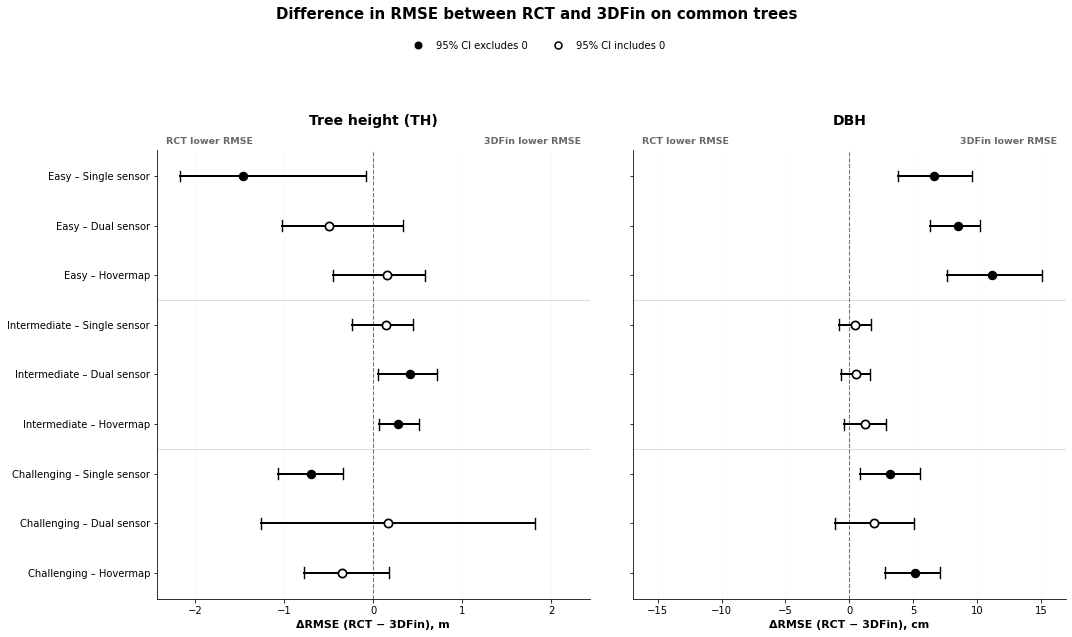

Saved: figure4_workflow_rmse_difference.png
Saved: figure4_workflow_rmse_difference.pdf


In [27]:
# Figure 4 directly compares 3DFin and RCT RMSE on the strict common-tree sample
# The plotted difference is: RMSE_RCT - RMSE_3DFin
# Negative values indicate lower RMSE for RCT
# Positive values indicate lower RMSE for 3DFin
# Filled circles show groups whose 95% bootstrap CI excludes zero
# Hollow circles show groups whose CI includes zero
# TH is displayed in metres and DBH in centimetres
# Start with the paired workflow-comparison bootstrap results

figure4_data = (
    workflow_rmse_bootstrap
    .copy()
)


# Keep TH in metres and convert DBH differences to centimetres so the effect sizes are easier to interpret
figure4_data[
    "Plot_delta"
] = (
    figure4_data[
        "Delta_RMSE_RCT_minus_3DFin"
    ]
)

figure4_data[
    "Plot_CI_lower"
] = (
    figure4_data[
        "CI_lower"
    ]
)

figure4_data[
    "Plot_CI_upper"
] = (
    figure4_data[
        "CI_upper"
    ]
)


dbh_mask = (
    figure4_data[
        "Attribute"
    ] == "DBH"
)


figure4_data.loc[
    dbh_mask,
    [
        "Plot_delta",
        "Plot_CI_lower",
        "Plot_CI_upper",
    ]
] = (
    figure4_data.loc[
        dbh_mask,
        [
            "Plot_delta",
            "Plot_CI_lower",
            "Plot_CI_upper",
        ]
    ]
    * 100
)


# Define the terrain and scanner order used on the y-axis
TERRAIN_ORDER = [
    "Easy",
    "Intermediate",
    "Challenging",
]

SCANNER_ORDER = [
    "Single sensor",
    "Dual sensor",
    "Hovermap",
]


row_order = []

for terrain in TERRAIN_ORDER:

    for scanner in SCANNER_ORDER:

        row_order.append(
            (
                terrain,
                scanner,
            )
        )


row_positions = {
    combination:
        len(row_order) - 1 - index

    for index, combination
    in enumerate(row_order)
}


figure4_data["y"] = (
    figure4_data.apply(
        lambda row:
        row_positions[
            (
                row["Terrain"],
                row["Scanner"],
            )
        ],
        axis=1,
    )
)


# Use a single colour because scanner identity is already shown explicitly in the y-axis labels
POINT_COLOUR = "#000000"
ZERO_COLOUR = "#777777"
SEPARATOR_COLOUR = "#D5D5D5"


# Create separate TH and DBH panels with a shared y-axis
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 8.5),
    sharey=True,
)


panel_settings = [
    (
        "TH",
        "Tree height (TH)",
        "ΔRMSE (RCT − 3DFin), m",
    ),
    (
        "DBH",
        "DBH",
        "ΔRMSE (RCT − 3DFin), cm",
    ),
]


for ax, (
    attribute,
    title,
    x_label,
) in zip(
    axes,
    panel_settings,
):

    panel = (
        figure4_data[
            figure4_data[
                "Attribute"
            ] == attribute
        ]
        .copy()
    )


    # Draw the RMSE difference and its 95% bootstrap confidence interval for each terrain × scanner combination
    for _, row in panel.iterrows():

        y = row["y"]

        estimate = row[
            "Plot_delta"
        ]

        ci_lower = row[
            "Plot_CI_lower"
        ]

        ci_upper = row[
            "Plot_CI_upper"
        ]


        ax.plot(
            [
                ci_lower,
                ci_upper,
            ],
            [
                y,
                y,
            ],
            color=POINT_COLOUR,
            linewidth=2.0,
            zorder=2,
        )


        # Add small end caps to the confidence interval
        cap_height = 0.11

        ax.plot(
            [
                ci_lower,
                ci_lower,
            ],
            [
                y - cap_height,
                y + cap_height,
            ],
            color=POINT_COLOUR,
            linewidth=1.4,
            zorder=2,
        )

        ax.plot(
            [
                ci_upper,
                ci_upper,
            ],
            [
                y - cap_height,
                y + cap_height,
            ],
            color=POINT_COLOUR,
            linewidth=1.4,
            zorder=2,
        )


        # Fill the point when the bootstrap confidence interval excludes zero
        # Otherwise show a hollow point
        if row[
            "CI_excludes_zero"
        ]:

            ax.scatter(
                estimate,
                y,
                s=68,
                marker="o",
                facecolor=POINT_COLOUR,
                edgecolor=POINT_COLOUR,
                linewidth=1.2,
                zorder=3,
            )

        else:

            ax.scatter(
                estimate,
                y,
                s=68,
                marker="o",
                facecolor="white",
                edgecolor=POINT_COLOUR,
                linewidth=1.7,
                zorder=3,
            )


    # Zero indicates identical RMSE for the two workflows
    ax.axvline(
        0,
        color=ZERO_COLOUR,
        linestyle="--",
        linewidth=1.1,
        zorder=1,
    )


    # Keep each panel symmetric around zero so the direction and magnitude of the workflow difference are easy to compare
    max_extent = max(
        abs(
            panel[
                "Plot_CI_lower"
            ].min()
        ),
        abs(
            panel[
                "Plot_CI_upper"
            ].max()
        ),
    )


    x_limit = (
        max_extent
        * 1.12
    )


    ax.set_xlim(
        -x_limit,
        x_limit,
    )


    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=25,
    )


    ax.set_xlabel(
        x_label,
        fontsize=11,
        fontweight="semibold",
    )


    # Add direction labels showing which workflow has lower RMSE
    ax.text(
        0.02,
        1.01,
        "RCT lower RMSE",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=9.5,
        fontweight="semibold",
        color="dimgray",
    )


    ax.text(
        0.98,
        1.01,
        "3DFin lower RMSE",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9.5,
        fontweight="semibold",
        color="dimgray",
    )


    # Apply light grid lines and remove unnecessary borders
    ax.grid(
        axis="x",
        linestyle=":",
        linewidth=0.6,
        alpha=0.25,
    )

    ax.set_axisbelow(
        True
    )

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )


# Label each terrain × scanner combination on the shared y-axis
y_ticks = []
y_labels = []


for terrain, scanner in row_order:

    y_ticks.append(
        row_positions[
            (
                terrain,
                scanner,
            )
        ]
    )

    y_labels.append(
        f"{terrain} – {scanner}"
    )


axes[0].set_yticks(
    y_ticks
)

axes[0].set_yticklabels(
    y_labels,
    fontsize=10,
)


# Separate the Easy, Intermediate and Challenging terrain groups
separator_positions = [
    5.5,
    2.5,
]


for ax in axes:

    for separator in separator_positions:

        ax.axhline(
            separator,
            color=SEPARATOR_COLOUR,
            linewidth=0.8,
            zorder=0,
        )


# Explain the filled and hollow point styles
legend_handles = [

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=POINT_COLOUR,
        markeredgecolor=POINT_COLOUR,
        markersize=7,
        label="95% CI excludes 0",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=POINT_COLOUR,
        markeredgewidth=1.5,
        markersize=7,
        label="95% CI includes 0",
    ),
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        0.995,
    ),
    ncol=2,
    frameon=False,
    fontsize=10,
)


fig.suptitle(
    "Difference in RMSE between RCT and 3DFin on common trees",
    fontsize=15,
    fontweight="bold",
    y=1.035,
)


fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.92,
    ],
    w_pad=4,
)


# Save Figure 4 in both PNG and PDF formats
figure4_png = (
    FIGURES_DIR
    / "figure4_workflow_rmse_difference.png"
)

figure4_pdf = (
    FIGURES_DIR
    / "figure4_workflow_rmse_difference.pdf"
)


fig.savefig(
    figure4_png,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    figure4_pdf,
    bbox_inches="tight",
)


plt.show()


print(
    f"Saved: {figure4_png.name}"
)

print(
    f"Saved: {figure4_pdf.name}"
)

In [28]:
# Save the final descriptive outputs and run a final audit of the main files produced by Notebook 03
# Save the strict common-tree sample used for the direct workflow comparison and the later mixed-effects analysis

common_sample_path = (
    TABLES_DIR
    / "postqc_common_tree_sample.csv"
)

final_metrics_path = (
    TABLES_DIR
    / "postqc_common_sample_metrics.csv"
)


final_common.to_csv(
    common_sample_path,
    index=False,
)

final_common_metrics.to_csv(
    final_metrics_path,
    index=False,
)


print(f"Saved: {common_sample_path.name}")
print(f"Saved: {final_metrics_path.name}")


# Check that the main tables and figures created by this notebook have been saved successfully

expected_outputs = [

    # RCT QC results:
    TABLES_DIR / "rct_qc_bootstrap_summary.csv",
    TABLES_DIR / "rct_qc_influence_check.csv",
    TABLES_DIR / "rct_qc_leave_one_out.csv",

    # Final common-tree results:
    TABLES_DIR / "postqc_common_tree_sample.csv",
    TABLES_DIR / "postqc_common_sample_metrics.csv",

    # Direct workflow comparison:
    TABLES_DIR / "workflow_rmse_bootstrap_summary.csv",
    TABLES_DIR / "workflow_rmse_bootstrap_draws.csv",

    # Main figures:
    FIGURES_DIR / "figure2_rct_qc_paired_change.png",
    FIGURES_DIR / "figure3_th_reference_vs_predicted.png",
    FIGURES_DIR / "figure3_dbh_reference_vs_predicted.png",
    FIGURES_DIR / "figure4_workflow_rmse_difference.png",
]


missing_outputs = []


for path in expected_outputs:

    if path.exists():

        print(
            f"OK  {path.name}"
        )

    else:

        print(
            f"MISSING  {path.name}"
        )

        missing_outputs.append(
            path
        )


# Check the expected size of the strict common-tree sample
require(
    len(final_common) == 462,
    "Final common sample should contain 462 observations.",
)


# Check the expected number of unique TH trees across the three terrain-specific common samples
require(
    final_common[
        final_common["Attribute"] == "TH"
    ]["GT_ID"]
    .groupby(
        final_common[
            final_common["Attribute"] == "TH"
        ]["Terrain"]
    )
    .nunique()
    .sum()
    == 29,
    "Expected 29 unique Terrain-specific TH trees.",
)


# Check the expected number of unique DBH trees across the three terrain-specific common samples
require(
    final_common[
        final_common["Attribute"] == "DBH"
    ]["GT_ID"]
    .groupby(
        final_common[
            final_common["Attribute"] == "DBH"
        ]["Terrain"]
    )
    .nunique()
    .sum()
    == 48,
    "Expected 48 unique Terrain-specific DBH trees.",
)


require(
    len(workflow_rmse_bootstrap) == 18,
    "Expected 18 workflow bootstrap comparisons.",
)


if missing_outputs:

    print(
        "\nNotebook 03 audit finished, "
        "but some expected files are missing."
    )

else:

    print(
        "\nNotebook 03 audit passed."
    )


print(
    "\nNOTE:"
    "\nOne workflow-bootstrap sensitivity check remains pending."
    "\nIt will be added after Notebook 04 identifies the extreme TH observation."
)

Saved: postqc_common_tree_sample.csv
Saved: postqc_common_sample_metrics.csv
OK  rct_qc_bootstrap_summary.csv
OK  rct_qc_influence_check.csv
OK  rct_qc_leave_one_out.csv
OK  postqc_common_tree_sample.csv
OK  postqc_common_sample_metrics.csv
OK  workflow_rmse_bootstrap_summary.csv
OK  workflow_rmse_bootstrap_draws.csv
OK  figure2_rct_qc_paired_change.png
OK  figure3_th_reference_vs_predicted.png
OK  figure3_dbh_reference_vs_predicted.png
OK  figure4_workflow_rmse_difference.png

Notebook 03 audit passed.

NOTE:
One workflow-bootstrap sensitivity check remains pending.
It will be added after Notebook 04 identifies the extreme TH observation.


### Sensitivity of the workflow RMSE comparison to the extreme TH observation

Residual diagnostics from the mixed-effects analysis identified one extreme TH observation: GT2 in the Challenging-terrain Dual-sensor RCT dataset.
To determine whether this observation materially influenced the direct workflow comparison, the paired RMSE bootstrap for the Challenging-terrain Dual-sensor TH group was repeated after removing GT2 from both the 3DFin and RCT vectors. Removing both values preserves the paired structure of the workflow comparison.

In [29]:
# An extreme TH observation was identified in the LMM diagnostics (Challenging × Dual sensor × RCT × GT2)
# Test whether the paired workflow RMSE comparison is sensitive to the extreme TH observation 
# GT2 is removed from both the 3DFin and RCT error vectors before repeating the bootstrap


# Select the affected Challenging Dual-sensor TH group
gt2_group = (
    workflow_pairs[
        (
            workflow_pairs["Terrain"]
            == "Challenging"
        )
        &
        (
            workflow_pairs["Scanner"]
            == "Dual sensor"
        )
        &
        (
            workflow_pairs["Attribute"]
            == "TH"
        )
    ]
    .copy()
)


require(
    len(gt2_group) == 13,
    (
        "Expected 13 paired trees in the "
        "Challenging Dual-sensor TH group."
    ),
)


require(
    (gt2_group["GT_ID"] == 2).sum() == 1,
    "Expected exactly one GT2 record.",
)


# Retrieve the corresponding result from the primary workflow bootstrap for comparison with the sensitivity analysis
primary_gt2_result = (
    workflow_rmse_bootstrap[
        (
            workflow_rmse_bootstrap["Terrain"]
            == "Challenging"
        )
        &
        (
            workflow_rmse_bootstrap["Scanner"]
            == "Dual sensor"
        )
        &
        (
            workflow_rmse_bootstrap["Attribute"]
            == "TH"
        )
    ]
    .copy()
)


require(
    len(primary_gt2_result) == 1,
    "Expected exactly one primary bootstrap result.",
)


# Remove GT2 from both workflows so the comparison remains paired
gt2_sensitivity_group = (
    gt2_group[
        gt2_group["GT_ID"] != 2
    ]
    .copy()
)


require(
    len(gt2_sensitivity_group) == 12,
    (
        "Expected 12 paired trees after "
        "removing GT2."
    ),
)


error_3dfin = (
    gt2_sensitivity_group["3DFin"]
    .to_numpy()
)

error_rct = (
    gt2_sensitivity_group["RCT"]
    .to_numpy()
)


# Recalculate the two RMSE values and their difference after excluding GT2
rmse_3dfin_sensitivity = np.sqrt(
    np.mean(
        error_3dfin ** 2
    )
)


rmse_rct_sensitivity = np.sqrt(
    np.mean(
        error_rct ** 2
    )
)


delta_rmse_sensitivity = (
    rmse_rct_sensitivity
    - rmse_3dfin_sensitivity
)


# Repeat the paired bootstrap using the same sampled tree positions for both workflow error vectors
rng = np.random.default_rng(
    WORKFLOW_BOOTSTRAP_SEED
)


n_trees = len(
    gt2_sensitivity_group
)


sensitivity_draws = np.empty(
    N_BOOTSTRAP_WORKFLOW
)


for bootstrap_i in range(
    N_BOOTSTRAP_WORKFLOW
):

    sampled_indices = rng.integers(
        0,
        n_trees,
        size=n_trees,
    )


    sampled_3dfin = (
        error_3dfin[
            sampled_indices
        ]
    )


    sampled_rct = (
        error_rct[
            sampled_indices
        ]
    )


    bootstrap_rmse_3dfin = np.sqrt(
        np.mean(
            sampled_3dfin ** 2
        )
    )


    bootstrap_rmse_rct = np.sqrt(
        np.mean(
            sampled_rct ** 2
        )
    )


    sensitivity_draws[
        bootstrap_i
    ] = (
        bootstrap_rmse_rct
        - bootstrap_rmse_3dfin
    )


ci_lower_sensitivity, ci_upper_sensitivity = (
    np.percentile(
        sensitivity_draws,
        [
            2.5,
            97.5,
        ],
    )
)


# Put the primary and GT2-excluded results side-by-side for direct comparison
primary_row = (
    primary_gt2_result
    .iloc[0]
)


workflow_gt2_sensitivity = pd.DataFrame(
    [
        {
            "Analysis":
                "Primary",
            "Terrain":
                "Challenging",
            "Scanner":
                "Dual sensor",
            "Attribute":
                "TH",
            "n":
                int(primary_row["n"]),
            "RMSE_3DFin":
                primary_row["RMSE_3DFin"],
            "RMSE_RCT":
                primary_row["RMSE_RCT"],
            "Delta_RMSE_RCT_minus_3DFin":
                primary_row[
                    "Delta_RMSE_RCT_minus_3DFin"
                ],
            "CI_lower":
                primary_row["CI_lower"],
            "CI_upper":
                primary_row["CI_upper"],
            "CI_excludes_zero":
                primary_row[
                    "CI_excludes_zero"
                ],
        },

        {
            "Analysis":
                "Sensitivity excluding GT2",
            "Terrain":
                "Challenging",
            "Scanner":
                "Dual sensor",
            "Attribute":
                "TH",
            "n":
                n_trees,
            "RMSE_3DFin":
                rmse_3dfin_sensitivity,
            "RMSE_RCT":
                rmse_rct_sensitivity,
            "Delta_RMSE_RCT_minus_3DFin":
                delta_rmse_sensitivity,
            "CI_lower":
                ci_lower_sensitivity,
            "CI_upper":
                ci_upper_sensitivity,
            "CI_excludes_zero":
                (
                    ci_lower_sensitivity > 0
                    or
                    ci_upper_sensitivity < 0
                ),
        },
    ]
)


print(
    "Challenging Dual-sensor TH "
    "workflow sensitivity\n"
)


print(
    workflow_gt2_sensitivity
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)


# Save both the comparison summary and the full set of sensitivity-bootstrap draws
sensitivity_summary_path = (
    TABLES_DIR
    / "workflow_rmse_gt2_sensitivity_summary.csv"
)


sensitivity_draws_path = (
    TABLES_DIR
    / "workflow_rmse_gt2_sensitivity_draws.csv"
)


workflow_gt2_sensitivity.to_csv(
    sensitivity_summary_path,
    index=False,
)


pd.DataFrame(
    {
        "Bootstrap_iteration":
            np.arange(
                1,
                N_BOOTSTRAP_WORKFLOW + 1,
            ),

        "Delta_RMSE_RCT_minus_3DFin":
            sensitivity_draws,
    }
).to_csv(
    sensitivity_draws_path,
    index=False,
)


print(
    f"\nSaved: {sensitivity_summary_path.name}"
)

print(
    f"Saved: {sensitivity_draws_path.name}"
)

Challenging Dual-sensor TH workflow sensitivity

                  Analysis      Terrain      Scanner Attribute   n  RMSE_3DFin  RMSE_RCT  Delta_RMSE_RCT_minus_3DFin  CI_lower  CI_upper  CI_excludes_zero
                   Primary  Challenging  Dual sensor        TH  13      2.4958    2.6573                      0.1615   -1.2564    1.8179             False
 Sensitivity excluding GT2  Challenging  Dual sensor        TH  12      2.5977    1.9092                     -0.6885   -1.5326    0.0166             False

Saved: workflow_rmse_gt2_sensitivity_summary.csv
Saved: workflow_rmse_gt2_sensitivity_draws.csv
